# Predictive Analytics: Deep Neural Network

In [1]:
import pandas as pd
import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
%run "3.2 Prediction_CommonGround.ipynb"


In [2]:
print(torch.cuda.is_available())
print(torch.__version__)

True
2.6.0+cu124


In [3]:
# Added a seed to make the results reproduceable
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed(RANDOM_STATE)

In [4]:
# Import the data-splits:

spatial_variants = ["census", "community", "h3_7"]
temporal_variants = ["daily", "hourly"]
SPATIAL_KEYS = {
    "h3_7": "h3_index_7",
    "census": "geoid10",
    "community": "commarea",
}

In [5]:
target = "Total_Trip_Start"
HOUR = ["hour_sin", "hour_cos"]
CALENDAR = ["month_sin", "month_cos", "is_weekend", "is_holiday", "is_near_holiday", "day_of_week"]
LOCATION = ["lat", "lon", "distance_to_loop"]
HISTORY = ["base_demand"]
POI_COLS = [
    "poi_cat_automotive", "poi_cat_civic_community", "poi_cat_education",
    "poi_cat_entertainment", "poi_cat_finance", "poi_cat_food_drink", "poi_cat_grocery",
    "poi_cat_health", "poi_cat_leisure_sports", "poi_cat_lodging", "poi_cat_nightlife",
    "poi_cat_services", "poi_cat_shopping", "poi_cat_transport"
]
WEATHER = ["2m_temp_c", "total_precip_mm", "snow_cov", "snow_depth", "wind_speed"]

features_hourly = HOUR + CALENDAR + LOCATION + HISTORY + POI_COLS + WEATHER
features_daily = CALENDAR + LOCATION + HISTORY + POI_COLS + WEATHER

In [6]:
# Preparing a dataframe, that contains all data-splits for each spatial and temporal resolution

prepared_data = []

for spatial in spatial_variants:
    for temporal in temporal_variants:
        print(f"Loading: {spatial} / {temporal}")

        df_train = pd.read_parquet(f"../data/prediction_split/{spatial}/{temporal}/train.parquet")
        df_val = pd.read_parquet(f"../data/prediction_split/{spatial}/{temporal}/val.parquet")
        df_test = pd.read_parquet(f"../data/prediction_split/{spatial}/{temporal}/test.parquet")

        features = features_hourly if temporal == "hourly" else features_daily

        n_per_class = int((df_train[target] > 0).sum())
        df_train_bal = balanced_sample(df_train, n_per_class)
        print(f"  balanced train: {len(df_train_bal)} rows "
              f"({(df_train_bal[target] > 0).mean():.1%} non-zero) from {len(df_train)}")

        # Fit the scaler on the FULL training split so val/test (true distribution) get scaled by
        # representative statistics, then transform the balanced training rows with that same scaler.
        x_scaler = StandardScaler()
        x_scaler.fit(df_train[features])

        X_train_t = torch.tensor(x_scaler.transform(df_train_bal[features]), dtype=torch.float32)
        y_train_t = torch.tensor(np.log1p(df_train_bal[target].values), dtype=torch.float32)
        X_val_t = torch.tensor(x_scaler.transform(df_val[features]), dtype=torch.float32)
        y_val_t = torch.tensor(np.log1p(df_val[target].values), dtype=torch.float32)
        X_test_t = torch.tensor(x_scaler.transform(df_test[features]), dtype=torch.float32)

        train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=250, shuffle=True)
        validation_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=250, shuffle=False)

        prepared_data.append({
            "spatial": spatial,
            "temporal": temporal,
            "input_layer": len(features),
            "X_val_t": X_val_t,
            "X_test_t": X_test_t,
            "y_val": df_val[target].values,
            "y_test": df_test[target].values,
            "train_loader": train_loader,
            "validation_loader": validation_loader,
            "df_test": df_test,
        })

print("Created all data-splits")

Loading: census / daily
  balanced train: 53438 rows (50.0% non-zero) from 258600
Loading: census / hourly
  balanced train: 366056 rows (50.0% non-zero) from 6206400
Loading: community / daily
  balanced train: 33187 rows (99.4% non-zero) from 33187
Loading: community / hourly
  balanced train: 796488 rows (57.5% non-zero) from 796488
Loading: h3_7 / daily
  balanced train: 21572 rows (50.0% non-zero) from 51289
Loading: h3_7 / hourly
  balanced train: 157588 rows (50.0% non-zero) from 1230936
Created all data-splits


In [7]:
# Definition of a hyperparameter grid:
learning_rate_variants = [0.01, 0.001, 0.0001]
hidden_layer_variants = [[64, 32, 16],[128, 64, 32], [128, 64, 32, 16], [256, 128, 64, 32]]
dropout_rate_variants = [0.0, 0.2]
weight_decay_variants = [0.0001] #Regularization for adam (with plain L2, adam would scale down the L2 gradient alongside the loss gradient. Adamw decouples weight decay from the gradient update)
epochs = 15 # Note: We use early stopping

In [8]:
# Definition of the feedforward NN:
# Notes: We make the number of hidden layers with the number of neurons dynamic, so we can try out different complexities in our grid-search
class FNN(nn.Module):
    def __init__(self, input_size, hidden_layers, dropout_rate):
        super(FNN, self).__init__()
        self.layers = nn.ModuleList()
        self.dropouts = nn.ModuleList()
        prev_size = input_size
        for hidden_size in hidden_layers:
            self.layers.append(nn.Linear(prev_size, hidden_size))
            self.dropouts.append(nn.Dropout(p=dropout_rate))
            prev_size = hidden_size
        self.output_layer = nn.Linear(prev_size, 1)

    def forward(self, x):
        for i in range(len(self.layers)):
            x = F.relu(self.layers[i](x))
            x = self.dropouts[i](x)
        return self.output_layer(x).squeeze(1)


In [9]:
# Definition of the training loop:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
print(device)

def train_model(FNN, device, train_loader, optimizer, loss_funct, epochs):
    FNN.train()
    loss_total = 0.0
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = FNN(inputs)
        loss = loss_funct(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_total += loss.item()
        running_loss += loss.item()
        if(i+1) % 250 == 0:
            print(f"TRAINING Epoch {epochs}, Batch {i+1}, Loss: {running_loss / 250}")
            running_loss = 0.0
    loss_avg = loss_total / len(train_loader)
    print(f"TRAINING Epoch {epochs}, Loss: {loss_avg}")
    return loss_avg



cuda


In [10]:
#Running the model on the validation split and return the avg loss
def validate_model(FNN, device, validation_loader, loss_funct):
    print("Predicting on Validation...")
    FNN.eval()
    loss_total = 0.0
    with torch.no_grad():
        for inputs, labels in validation_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = FNN(inputs)
            loss = loss_funct(outputs, labels)
            loss_total += loss.item()
    loss_avg = loss_total / len(validation_loader)
    print(f"VALIDATION, Loss: {loss_avg}")
    return loss_avg


In [11]:
# Grid-search for each hyperparameter combination defined before.
# Train the model for each batch in one epoch and validate the model after each epoch on the validation set
# We use early stopping, so we can make model training more efficient. Otherwise, we would train models long after they started overfitting

from IPython.display import clear_output, display

loss_funct = nn.MSELoss()
max_epochs_without_improvement = 3
all_results = {}
all_scores = []

for data in prepared_data:
    spatial = data["spatial"]
    temporal = data["temporal"]
    input_layer = data["input_layer"]
    X_val_t = data["X_val_t"]
    X_test_t = data["X_test_t"]
    y_val = data["y_val"]
    y_test = data["y_test"]
    train_loader = data["train_loader"]
    validation_loader = data["validation_loader"]
    df_test = data["df_test"]

    print(f"\n{"="*60}")
    print(f"Training: {spatial} / {temporal}")
    print(f"{"="*60}")

    results_df = pd.DataFrame(columns=["config", "layers", "lr", "dropout_rate", "weight_decay", "epoch", "train_loss", "val_loss"])

    for hidden_variant in hidden_layer_variants:
        for learning_rate in learning_rate_variants:
            for dropout_rate in dropout_rate_variants:
                for weight_decay in weight_decay_variants:
                    config_name = f"{spatial}_{temporal}_layers={hidden_variant}_lr={learning_rate}_dr={dropout_rate}_wd={weight_decay}"
                    model = FNN(input_layer, hidden_variant, dropout_rate).to(device)
                    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

                    epochs_without_improvement = 0
                    best_val_loss = None

                    for epoch_index in range(1, epochs+1):
                        train_loss = train_model(model, device, train_loader, optimizer, loss_funct, epoch_index)
                        val_loss = validate_model(model, device, validation_loader, loss_funct)

                        if best_val_loss is None or val_loss < best_val_loss:
                            best_val_loss = val_loss
                            epochs_without_improvement = 0
                            torch.save(model.state_dict(), f"../models_predictions/FNN/standard/{spatial}/trained_models/best_{config_name}.pth")
                        else:
                            epochs_without_improvement += 1

                        results_df.loc[len(results_df)] = {
                            "config": config_name,
                            "layers": str(hidden_variant),
                            "lr": learning_rate,
                            "dropout_rate": dropout_rate,
                            "weight_decay": weight_decay,
                            "epoch": epoch_index,
                            "train_loss": train_loss,
                            "val_loss": val_loss
                        }

                        clear_output(wait=True)
                        display(results_df.set_index(["config", "epoch"]))

                        if epochs_without_improvement >= max_epochs_without_improvement:
                            print(f"Early stopping at epoch {epoch_index} for {config_name}")
                            break
    all_results[(spatial, temporal)] = results_df.copy() 

    # For each config, load its best model and compute the val MAE in normal space (not in the log1 space)
    val_maes = {}
    for config_name in results_df["config"].unique():
        layers = eval(results_df[results_df["config"] == config_name]["layers"].iloc[0])
        dropout_rate_val = results_df[results_df["config"] == config_name]["dropout_rate"].iloc[0]
        m = FNN(input_layer, layers, dropout_rate_val)
        m.load_state_dict(torch.load(f"../models_predictions/FNN/standard/{spatial}/trained_models/best_{config_name}.pth", map_location="cpu"))
        m.eval()
        with torch.no_grad():
            val_preds = np.clip(np.expm1(m(X_val_t.cpu()).numpy()), 0, None)
        val_maes[config_name] = mean_absolute_error(y_val, val_preds)

    best_config = min(val_maes, key=val_maes.get)
    best_layers = eval(results_df[results_df["config"] == best_config]["layers"].iloc[0])
    best_dropout = results_df[results_df["config"] == best_config]["dropout_rate"].iloc[0]
    print(f"\nBest config: {best_config}, val MAE: {val_maes[best_config]:.4f}")

    model = FNN(input_layer, best_layers, best_dropout)
    model.load_state_dict(torch.load(f"../models_predictions/FNN/standard/{spatial}/trained_models/best_{best_config}.pth", map_location="cpu"))
    model.eval()
    torch.save(model.state_dict(), f"../models_predictions/FNN/standard/{spatial}/trained_models/best_fnn_{best_config}.pth")

    with torch.no_grad():
        y_pred_test = np.clip(np.expm1(model(X_test_t.cpu()).numpy().flatten()), 0, None)

    mae = mean_absolute_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    print(f"MAE: {mae:.4f} | R²: {r2:.4f} | RMSE: {rmse:.4f}")

    baseline_mae = mean_absolute_error(y_test, df_test["base_demand"].values)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, df_test["base_demand"].values))

    #See the description for skill() in the Notebook 3.2 Prediction_CommonGround.ipynb
    scores = skill({"MAE": mae, "RMSE": rmse}, {"MAE": baseline_mae, "RMSE": baseline_rmse})
    all_scores.append({
        "spatial": spatial,
        "temporal": temporal,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "skill_MAE": scores["skill_MAE"],
        "skill_RMSE": scores["skill_RMSE"],
    })

    spatial_key = SPATIAL_KEYS[spatial]
    pd.DataFrame({
        spatial_key: df_test[spatial_key].values,
        "timestamp": df_test["timestamp"].values,
        "y_true": y_test,
        "y_pred": y_pred_test,
    }).to_parquet(f"../models_predictions/FNN/standard/{spatial}/FNN_{spatial}_{temporal}.parquet", index=False)

layers  \
config                                             epoch                       
h3_7_hourly_layers=[64, 32, 16]_lr=0.01_dr=0.0_... 1            [64, 32, 16]   
                                                   2            [64, 32, 16]   
                                                   3            [64, 32, 16]   
                                                   4            [64, 32, 16]   
                                                   5            [64, 32, 16]   
...                                                                      ...   
h3_7_hourly_layers=[256, 128, 64, 32]_lr=0.0001... 6      [256, 128, 64, 32]   
                                                   7      [256, 128, 64, 32]   
                                                   8      [256, 128, 64, 32]   
                                                   9      [256, 128, 64, 32]   
                                                   10     [256, 128, 64, 32]   

                                                              lr  \
config                                             epoch           
h3_7_hourly_layers=[64, 32, 16]_lr=0.01_dr=0.0_... 1      0.0100   
                                                   2      0.0100   
                                                   3      0.0100   
                                                   4      0.0100   
                                                   5      0.0100   
...                                                          ...   
h3_7_hourly_layers=[256, 128, 64, 32]_lr=0.0001... 6      0.0001   
                                                   7      0.0001   
                                                   8      0.0001   
                                                   9      0.0001   
                                                   10     0.0001   

                                                          dropout_rate  \
config                                             epoch                 
h3_7_hourly_layers=[64, 32, 16]_lr=0.01_dr=0.0_... 1               0.0   
                                                   2               0.0   
                                                   3               0.0   
                                                   4               0.0   
                                                   5               0.0   
...                                                                ...   
h3_7_hourly_layers=[256, 128, 64, 32]_lr=0.0001... 6               0.2   
                                                   7               0.2   
                                                   8               0.2   
                                                   9               0.2   
                                                   10              0.2   

                                                          weight_decay  \
config                                             epoch                 
h3_7_hourly_layers=[64, 32, 16]_lr=0.01_dr=0.0_... 1            0.0001   
                                                   2            0.0001   
                                                   3            0.0001   
                                                   4            0.0001   
                                                   5            0.0001   
...                                                                ...   
h3_7_hourly_layers=[256, 128, 64, 32]_lr=0.0001... 6            0.0001   
                                                   7            0.0001   
                                                   8            0.0001   
                                                   9            0.0001   
                                                   10           0.0001   

                                                          train_loss  val_loss  
config                                             epoch                        
h3_7_hourly_layers=[64, 32, 16]_lr=0.01_dr=0.0_... 1    

Early stopping at epoch 10 for h3_7_hourly_layers=[256, 128, 64, 32]_lr=0.0001_dr=0.2_wd=0.0001

Best config: h3_7_hourly_layers=[256, 128, 64, 32]_lr=0.001_dr=0.2_wd=0.0001, val MAE: 0.9133
MAE: 1.0612 | R²: 0.8881 | RMSE: 7.3082


In [12]:
scores_df = pd.DataFrame(all_scores).sort_values("skill_MAE", ascending=False)
print(scores_df.to_string(index=False))

  spatial temporal       MAE       RMSE       R2  skill_MAE  skill_RMSE
     h3_7    daily 18.178660 106.267051 0.930631   0.089355    0.094035
community   hourly  3.050150  11.860780 0.898943  -0.023043   -0.067730
     h3_7   hourly  1.061231   7.308221 0.888095  -0.047300   -0.010178
   census   hourly  0.255197   1.969716 0.870032  -0.067575    0.006781
community    daily 55.740177 205.567306 0.918592  -0.125767   -0.143819
   census    daily  5.034840  32.661900 0.887703  -0.189183   -0.160968


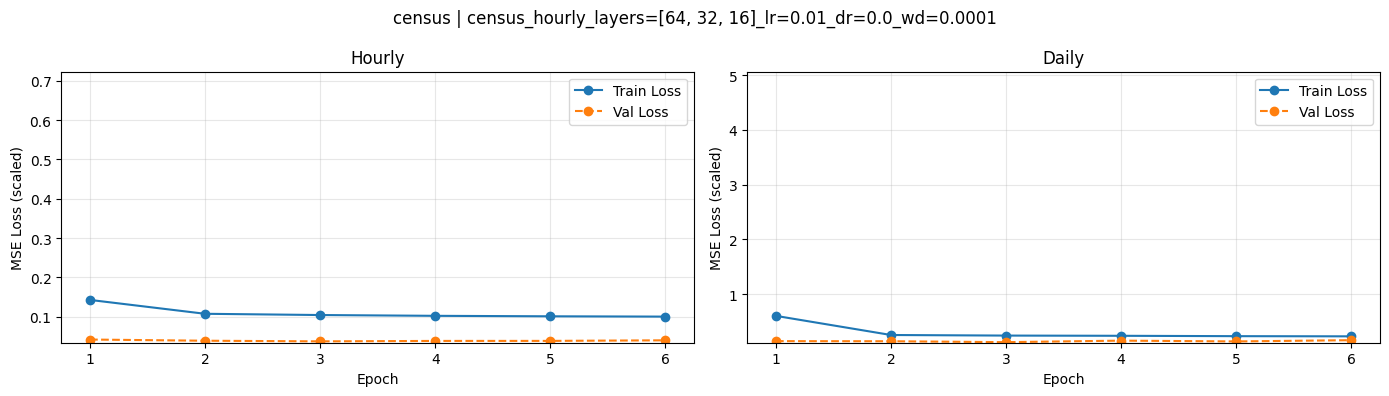

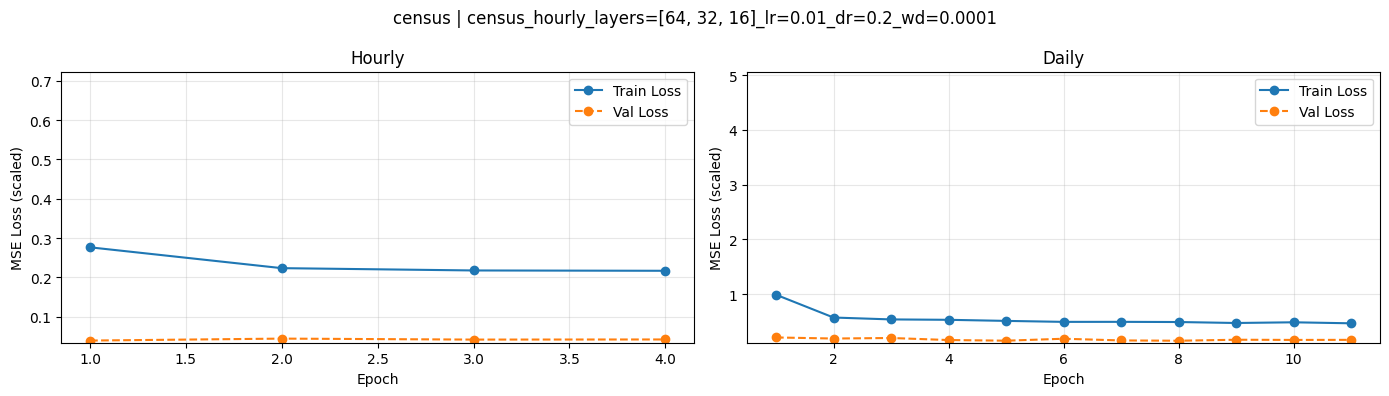

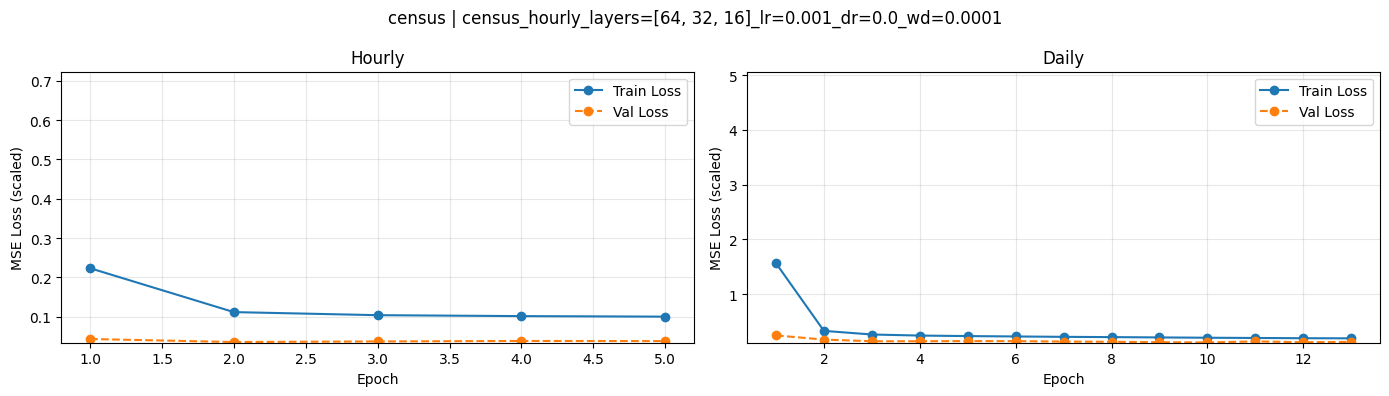

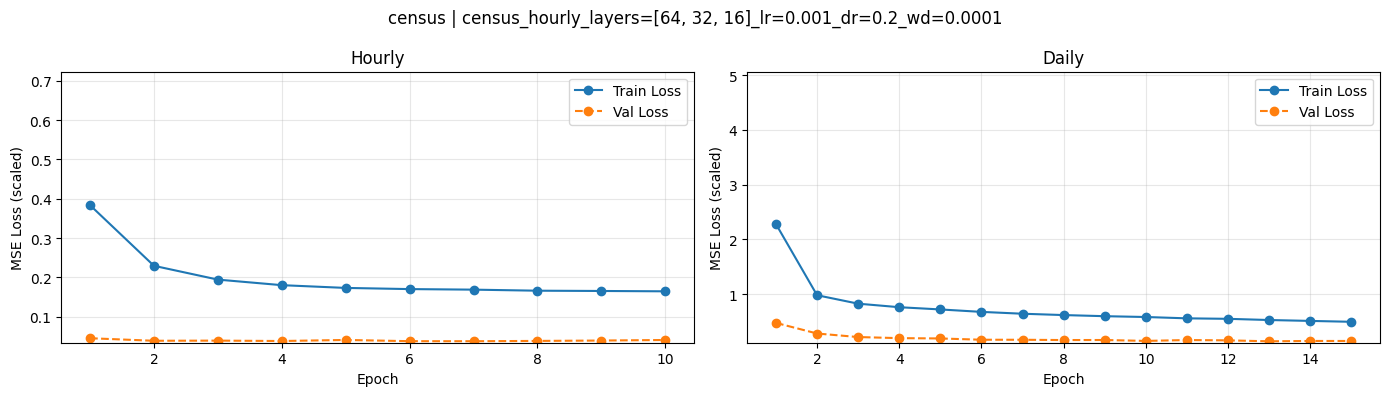

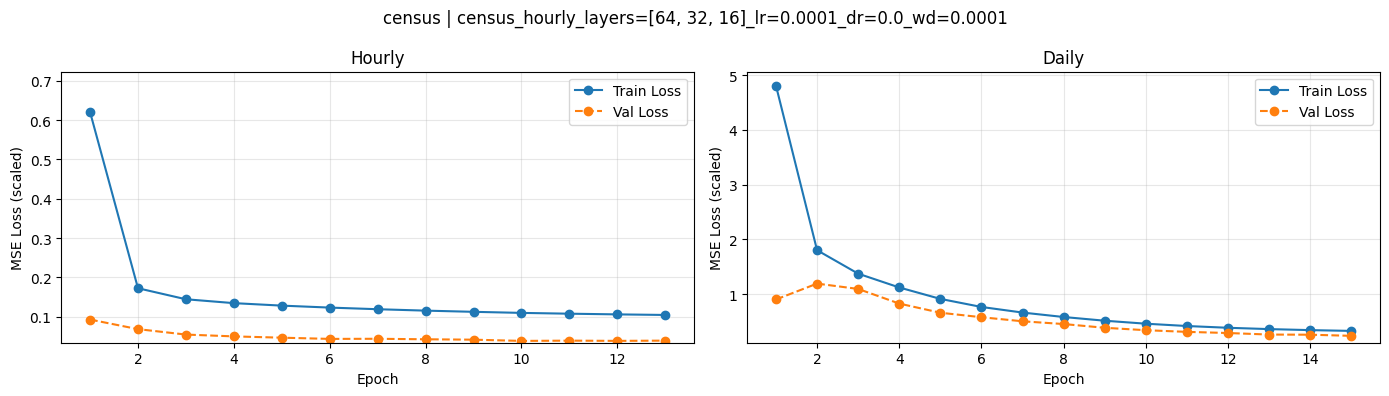

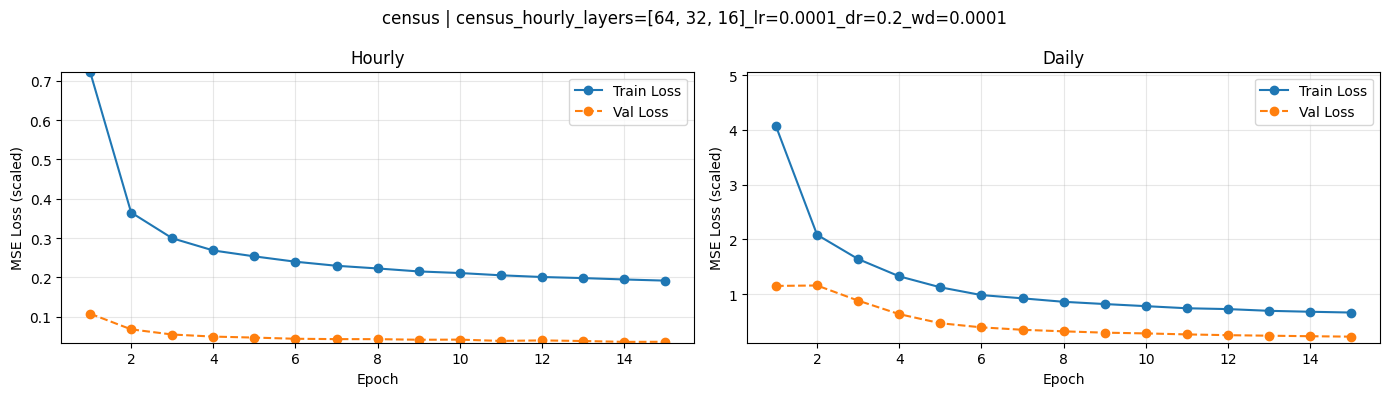

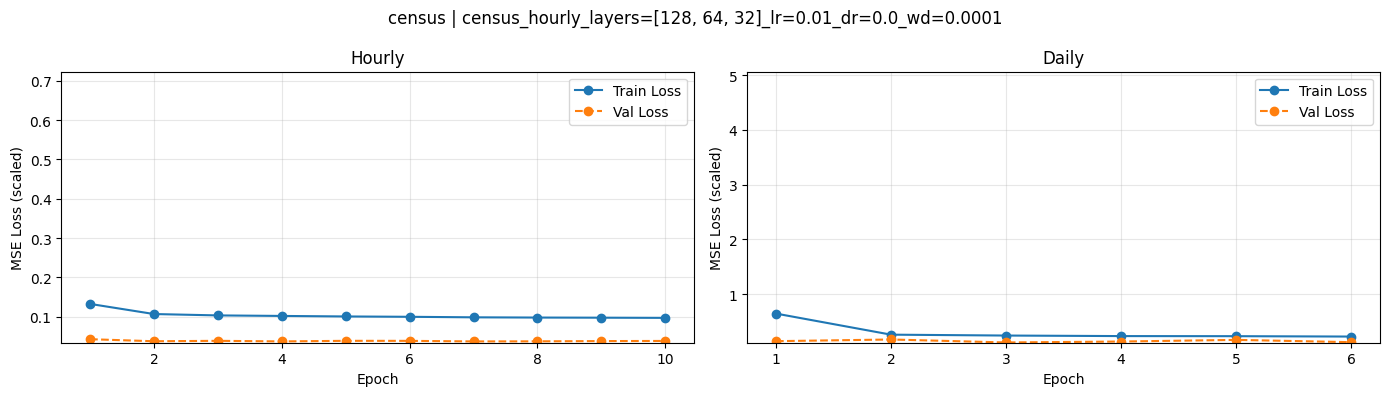

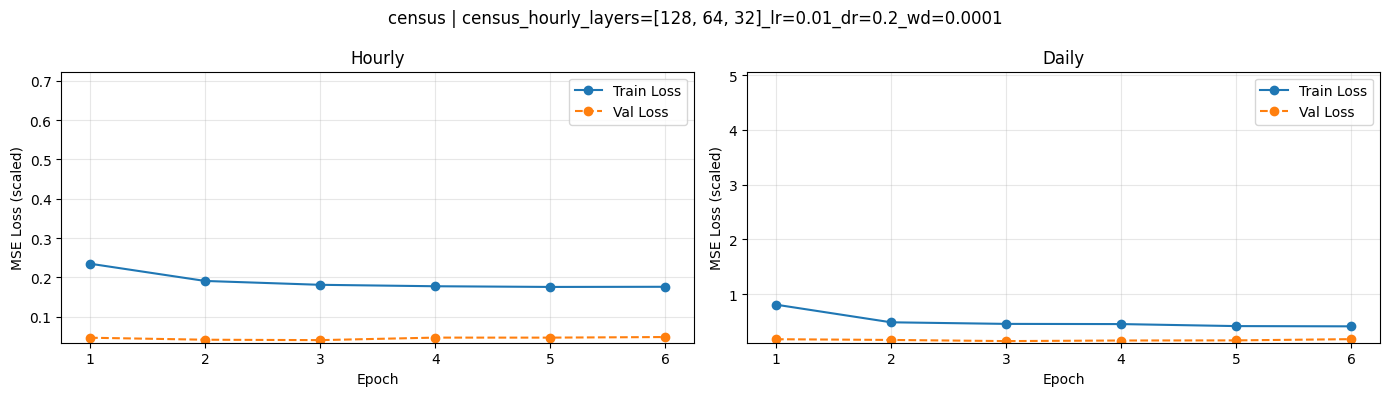

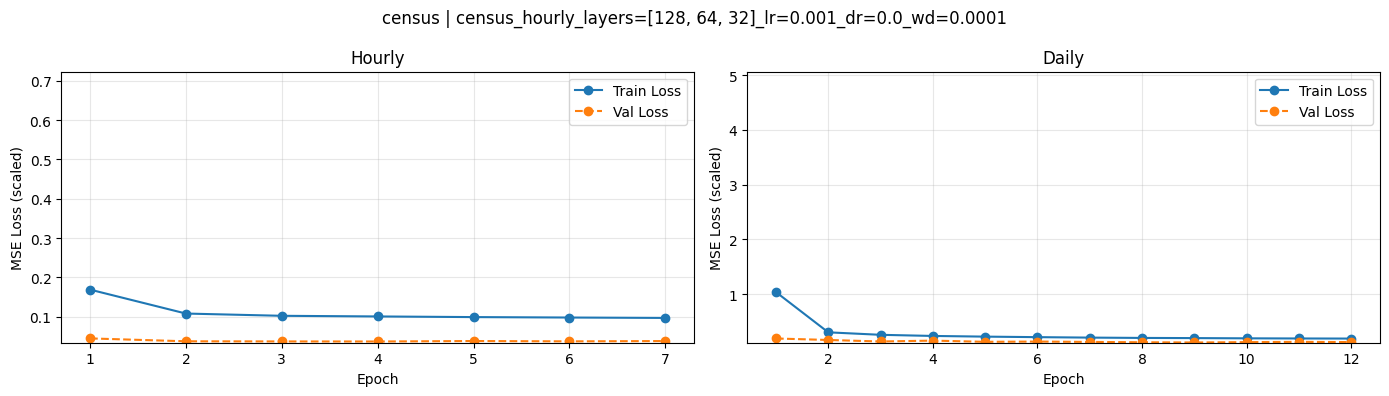

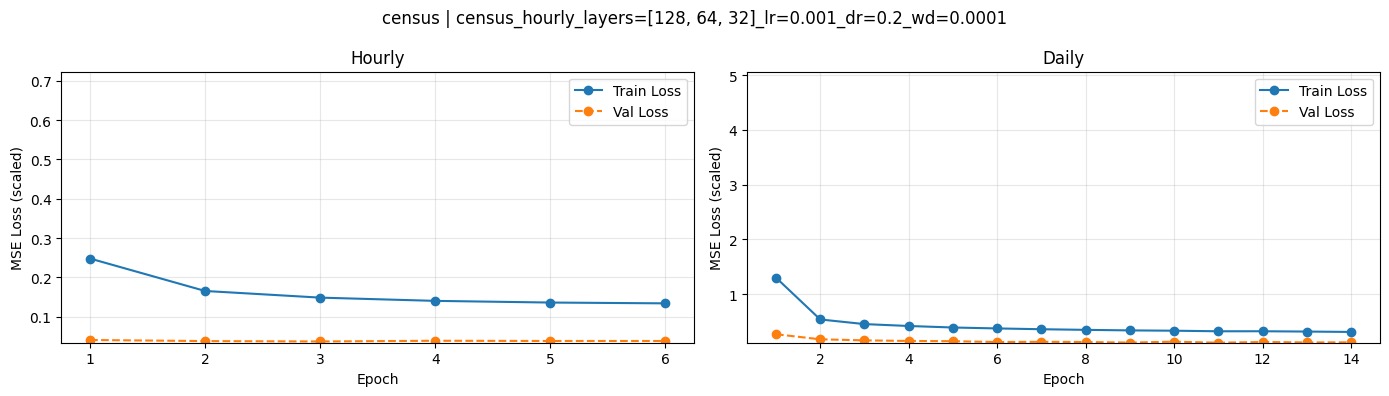

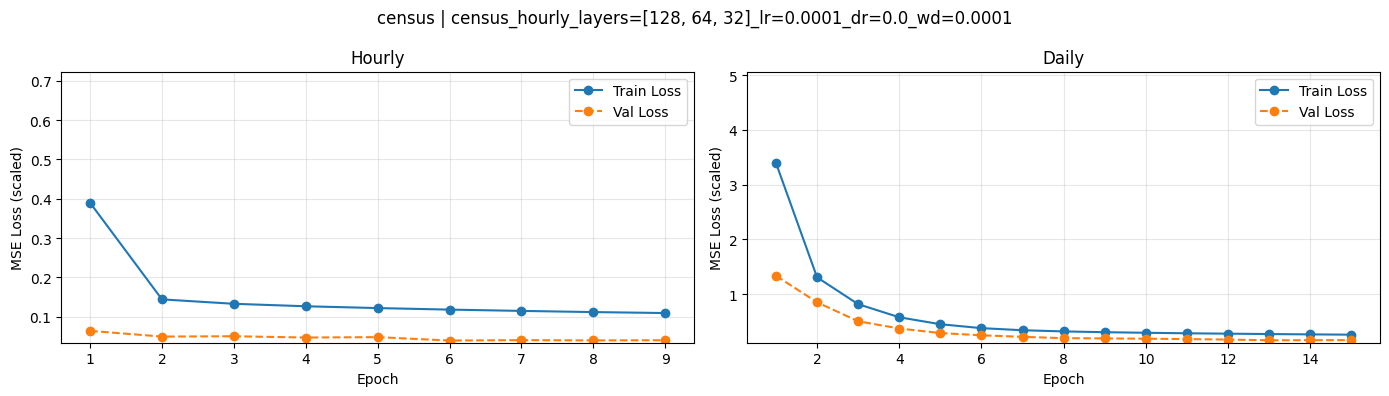

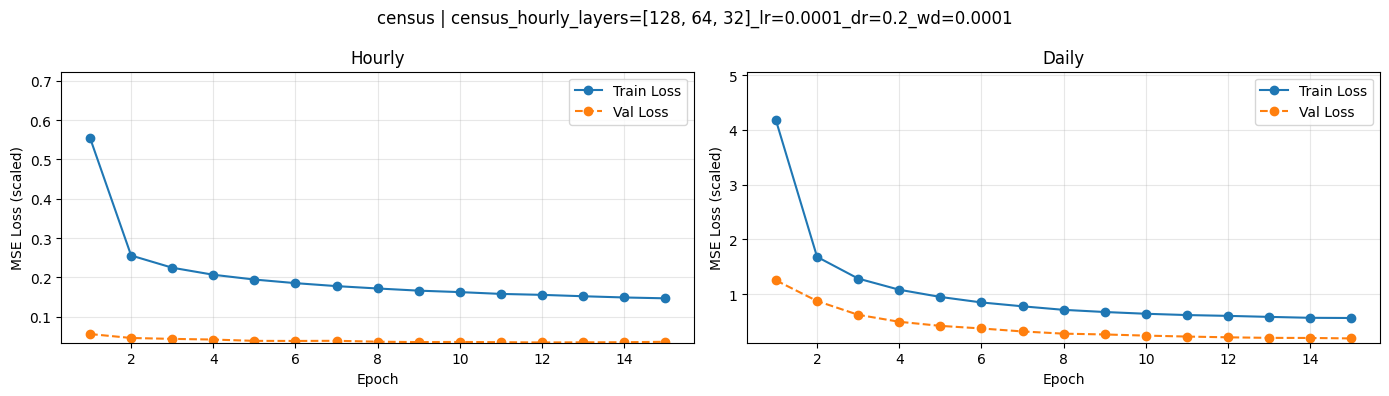

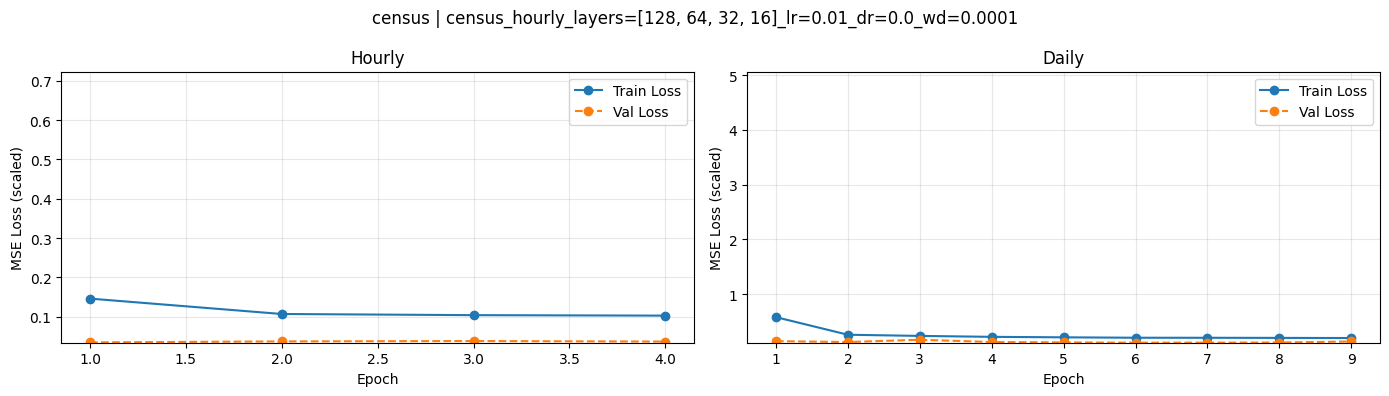

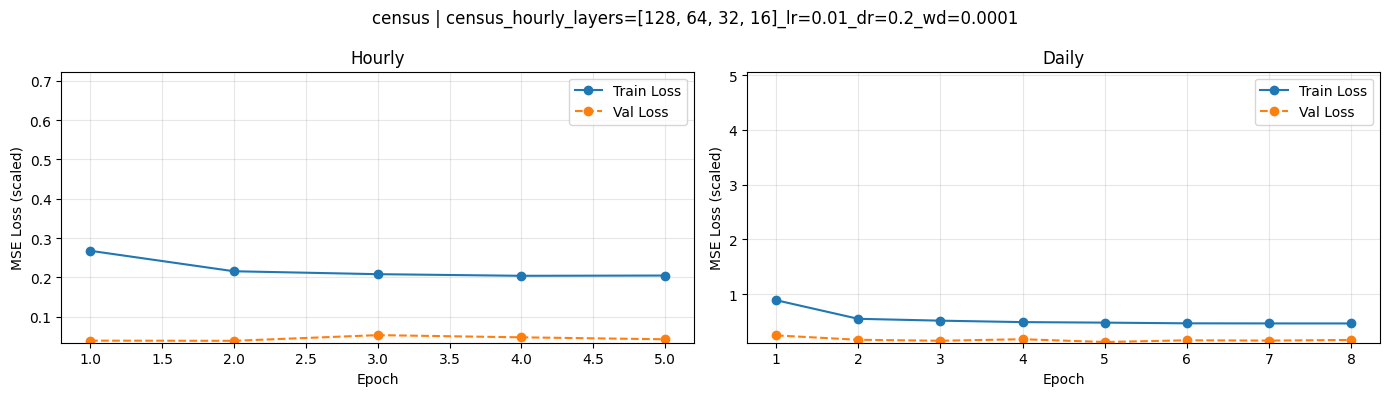

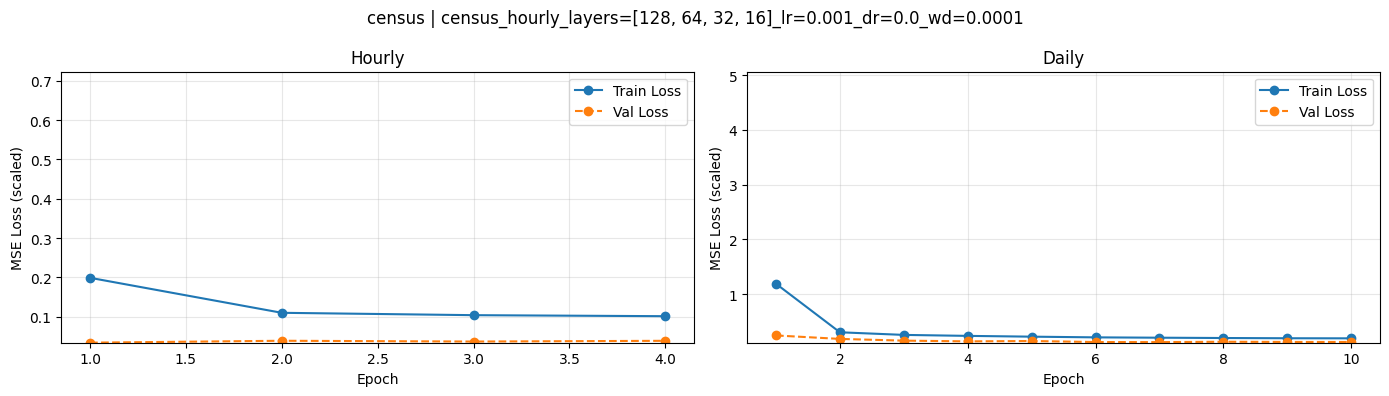

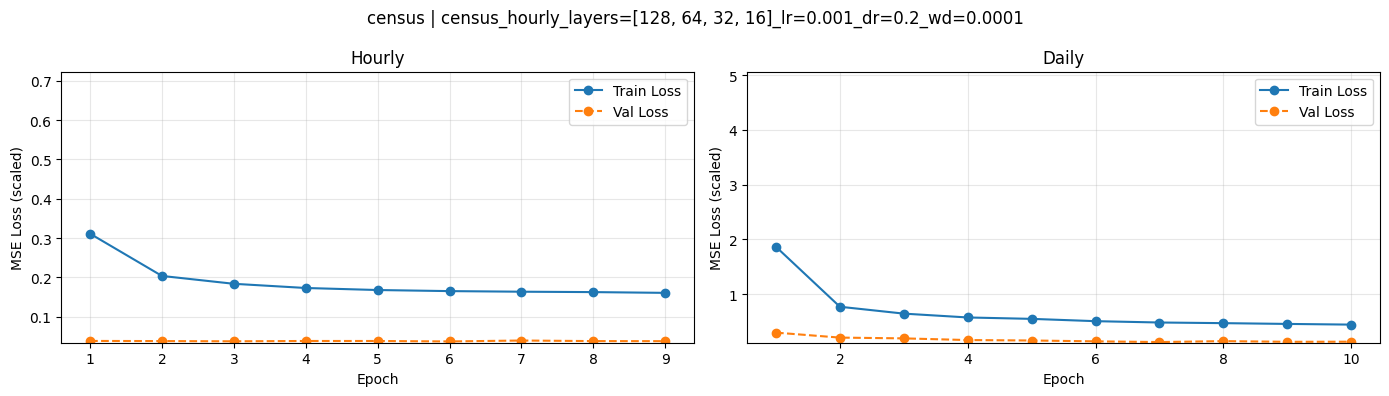

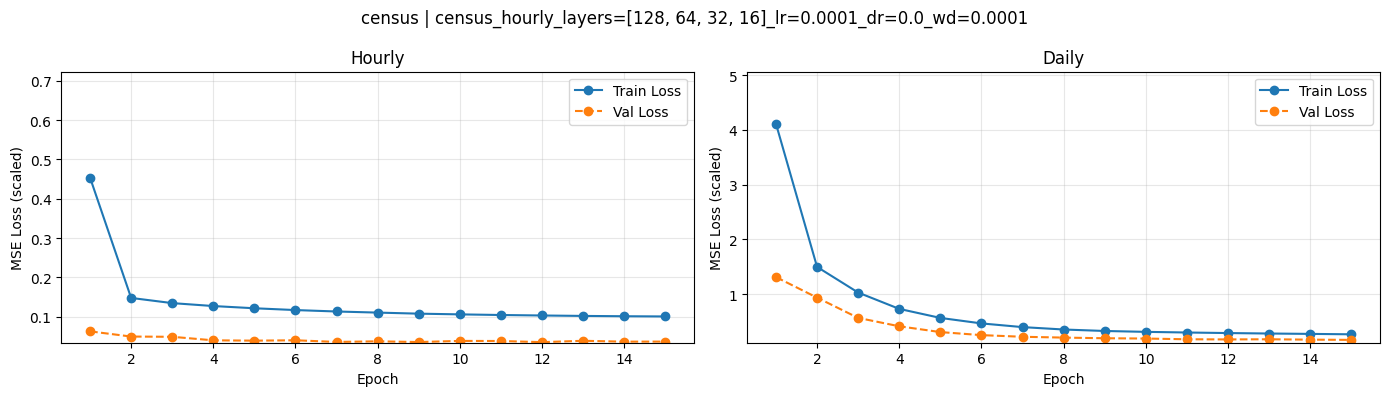

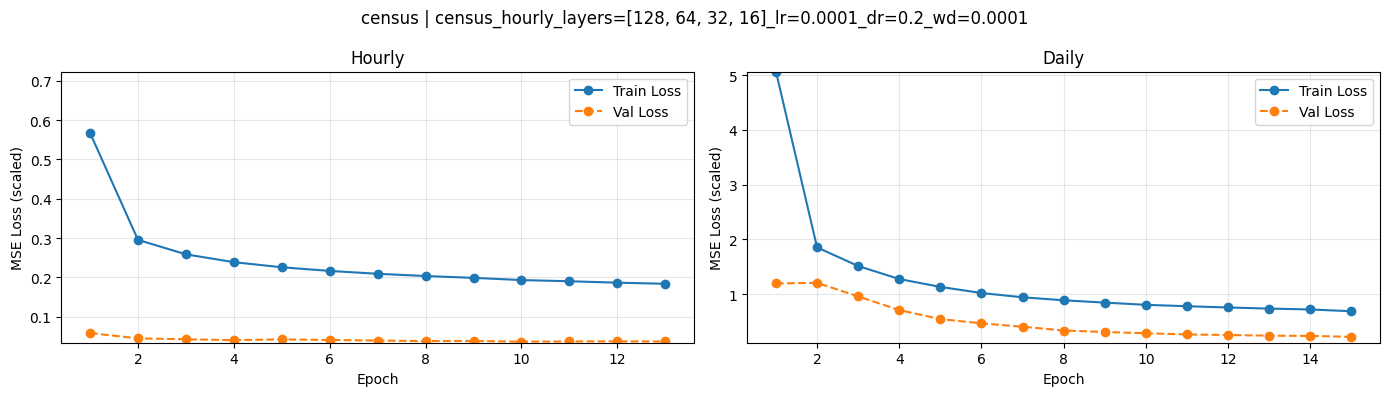

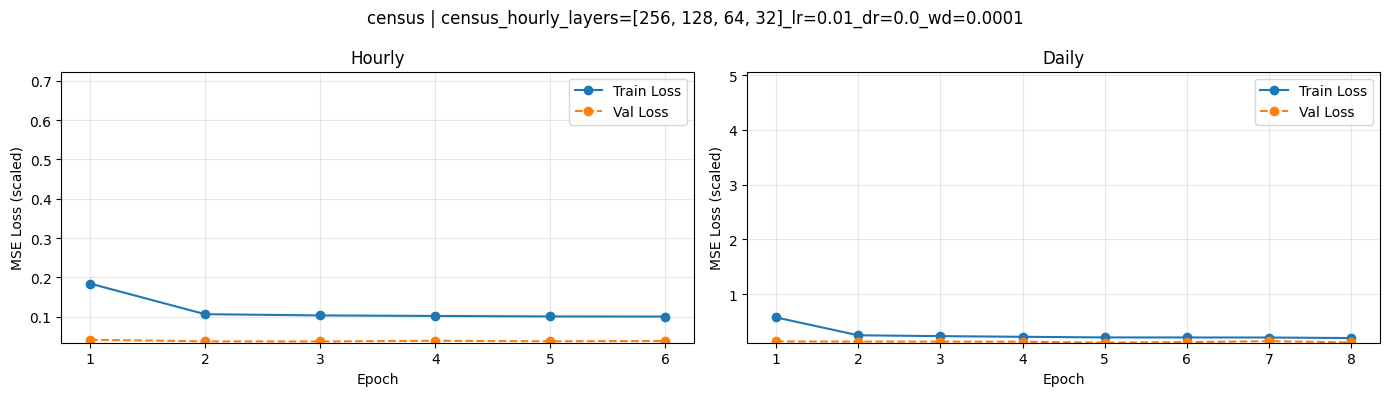

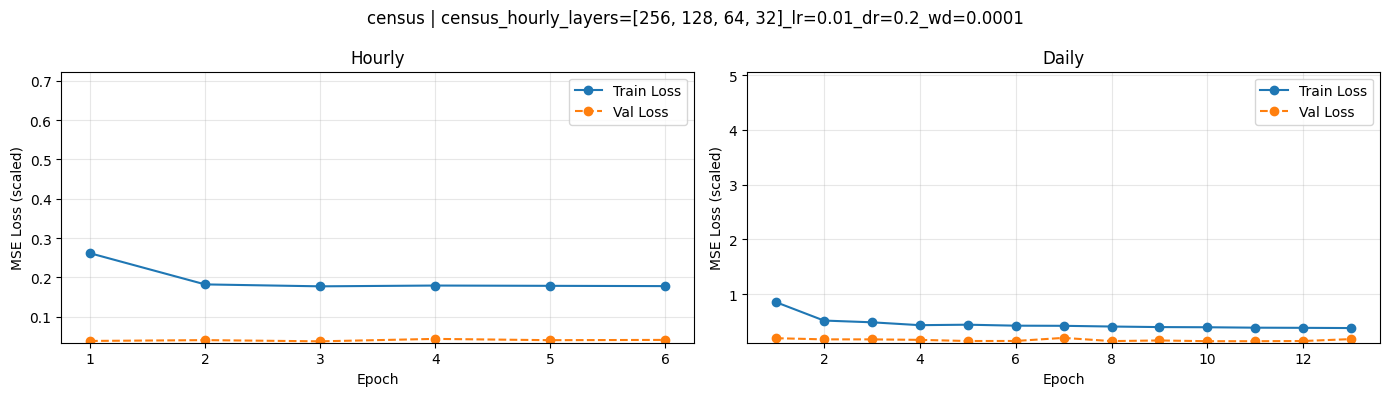

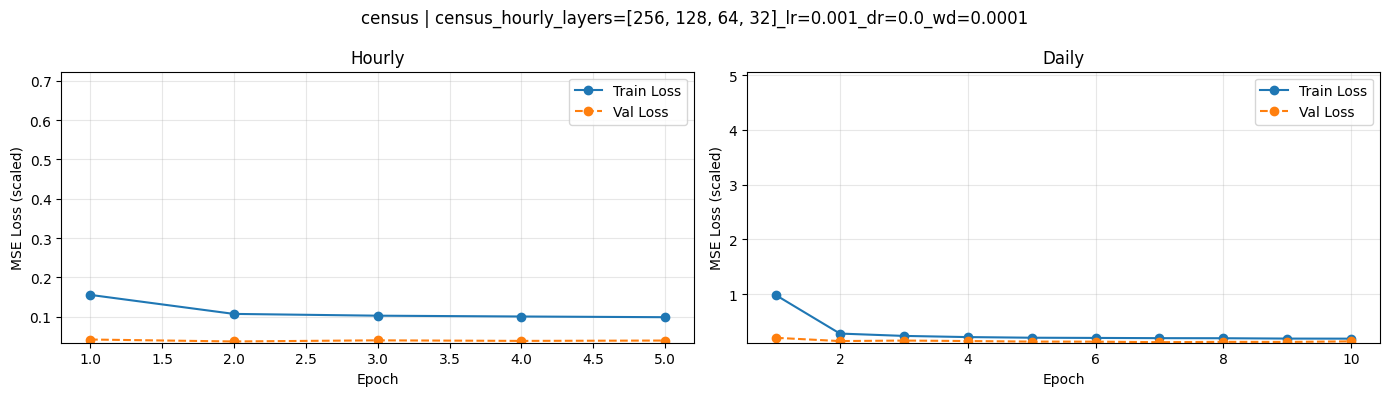

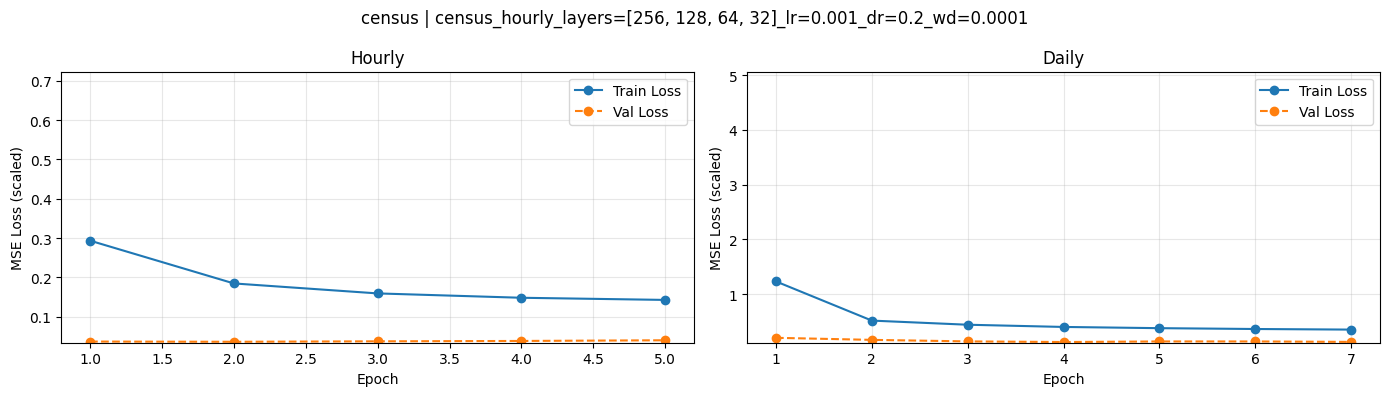

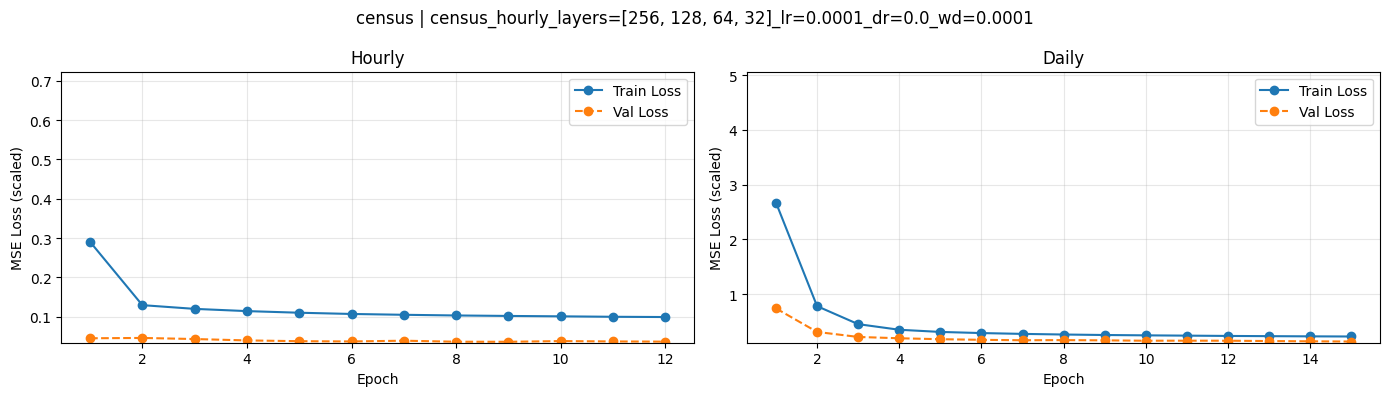

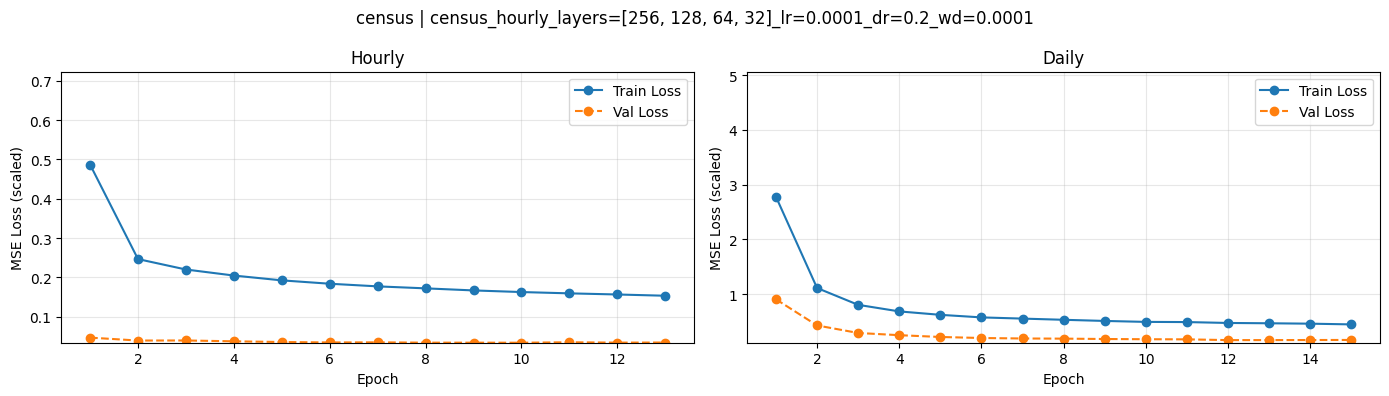

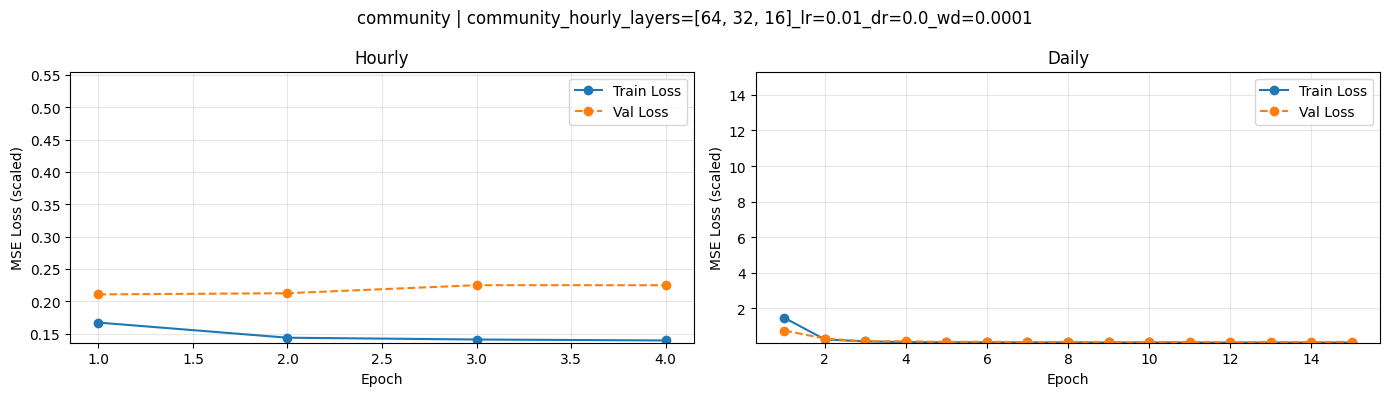

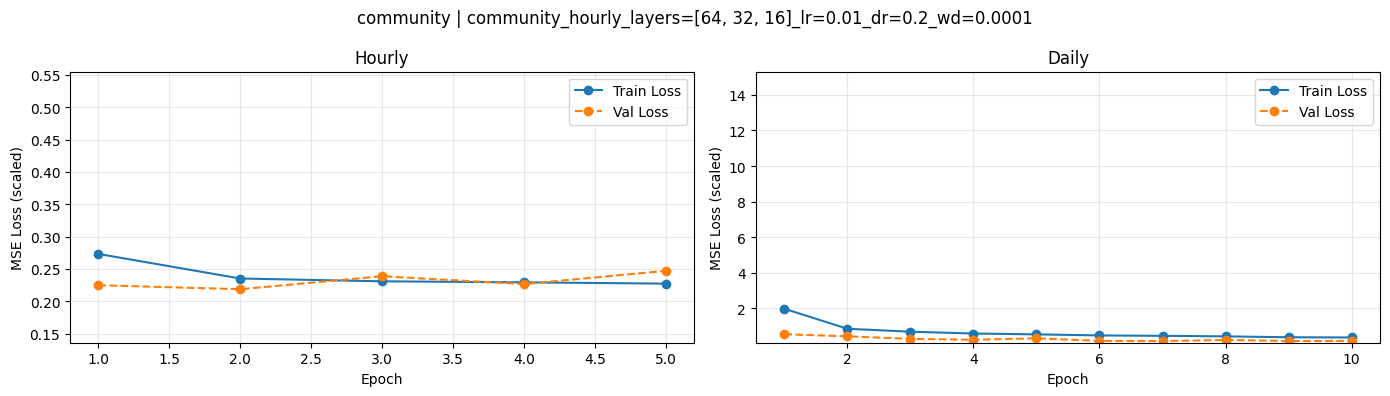

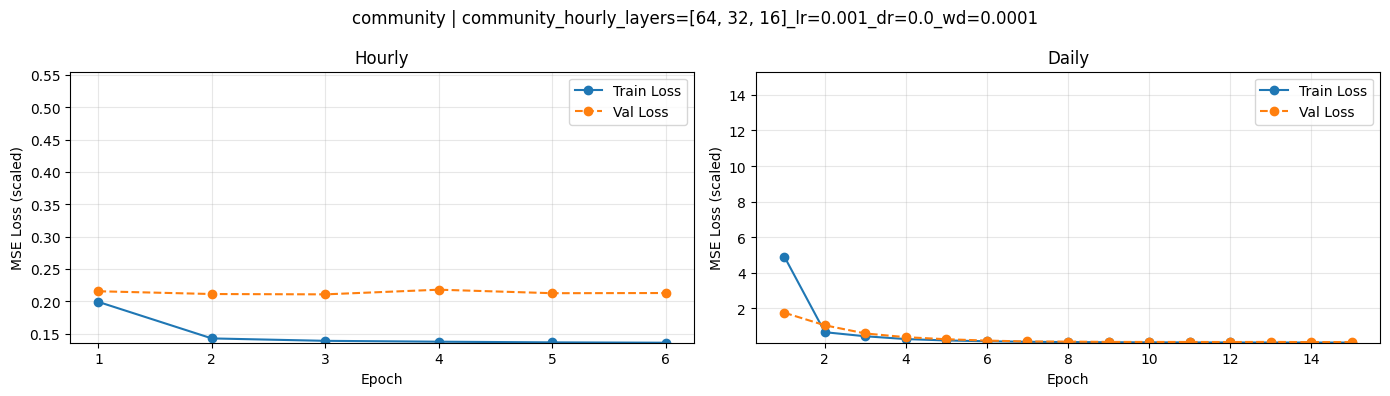

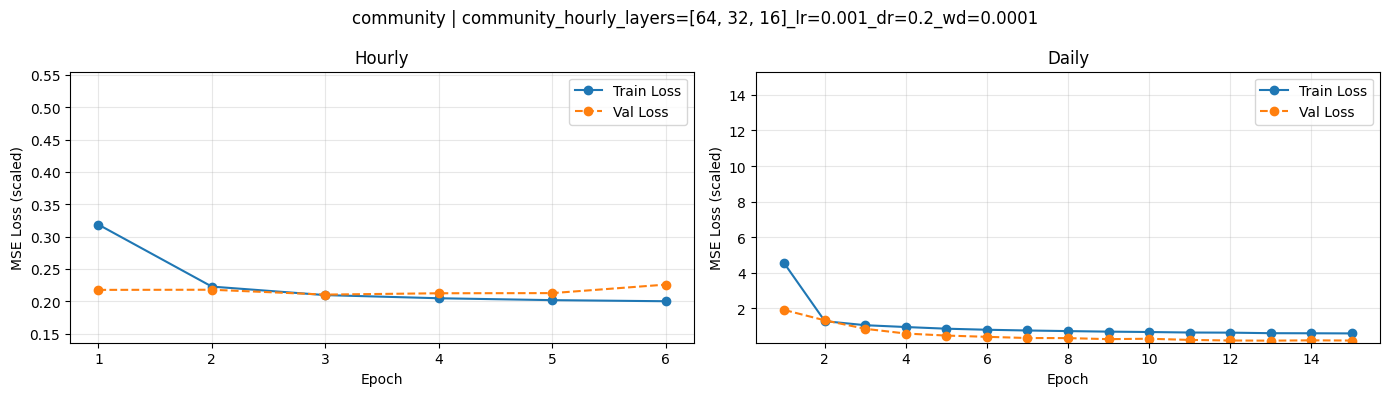

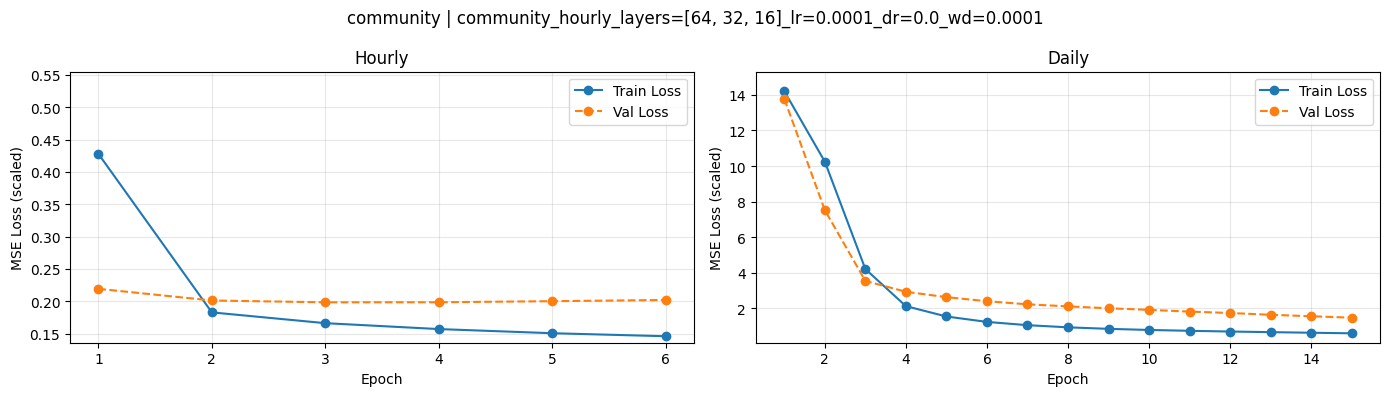

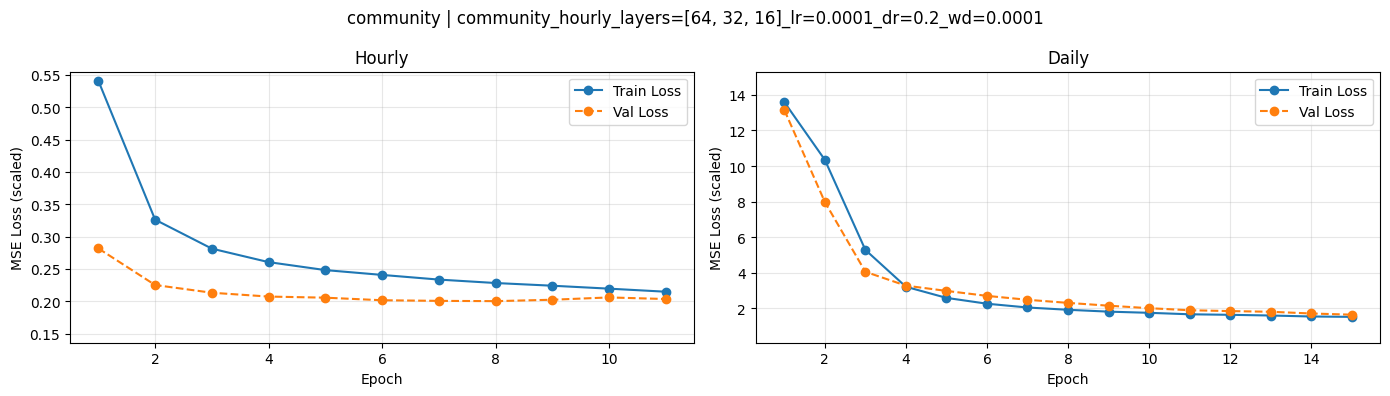

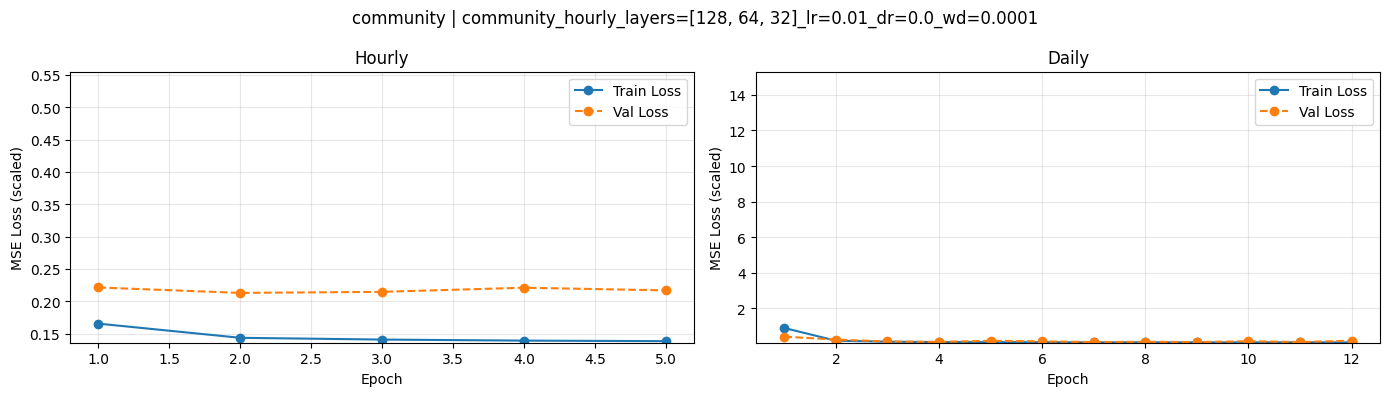

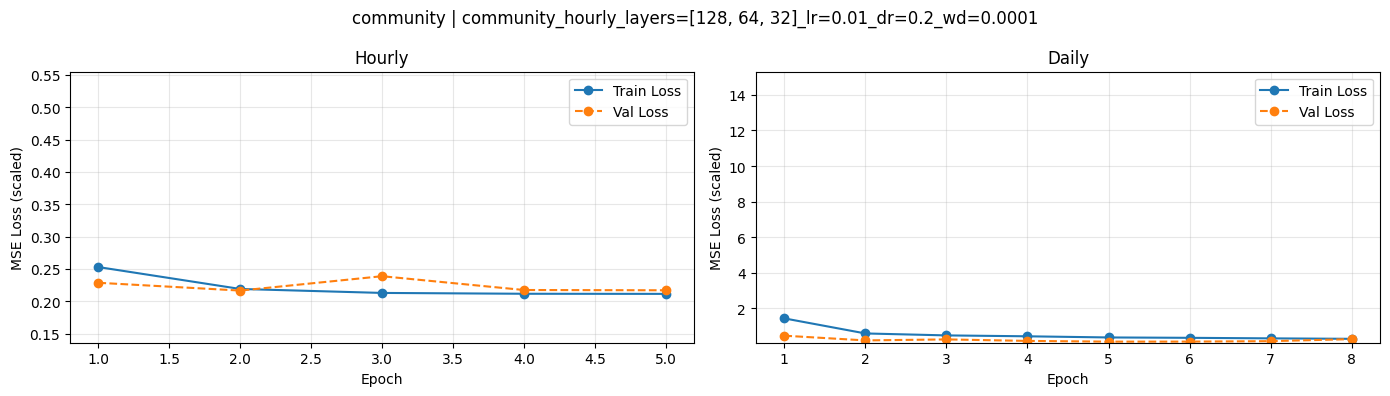

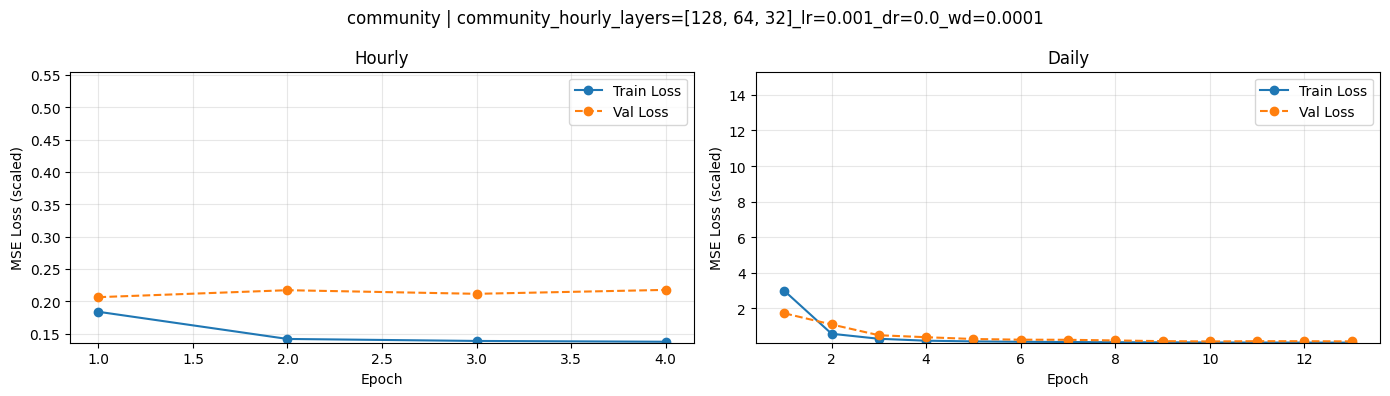

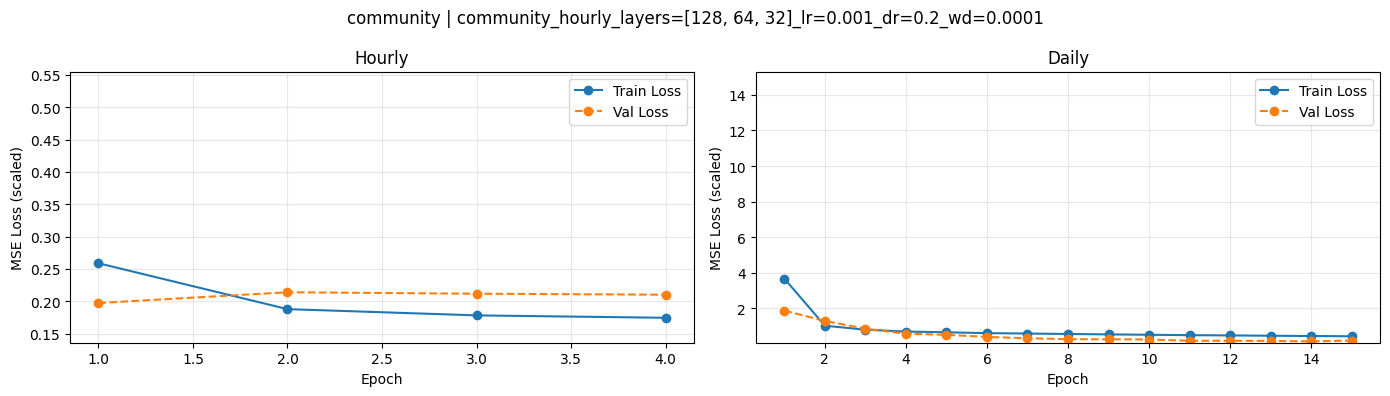

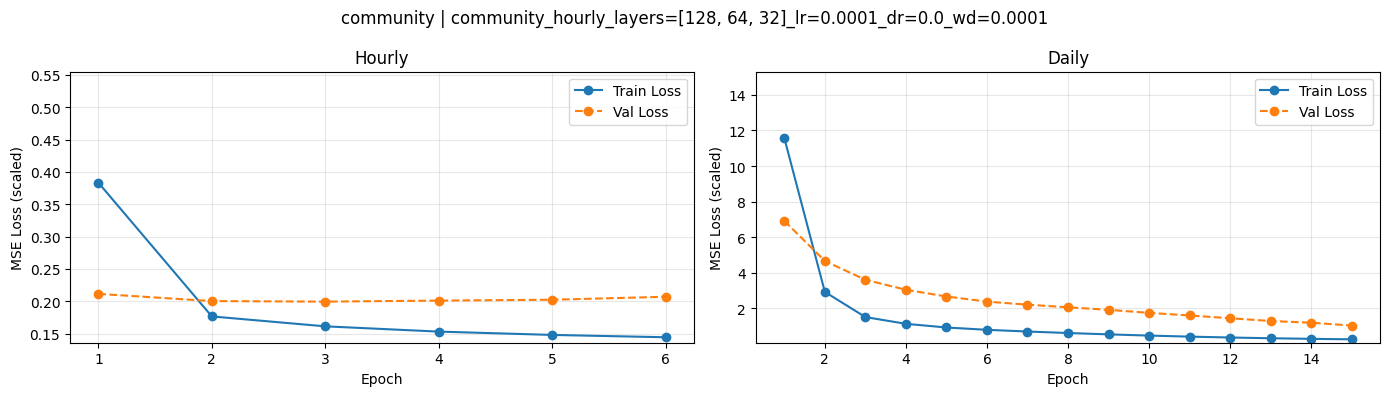

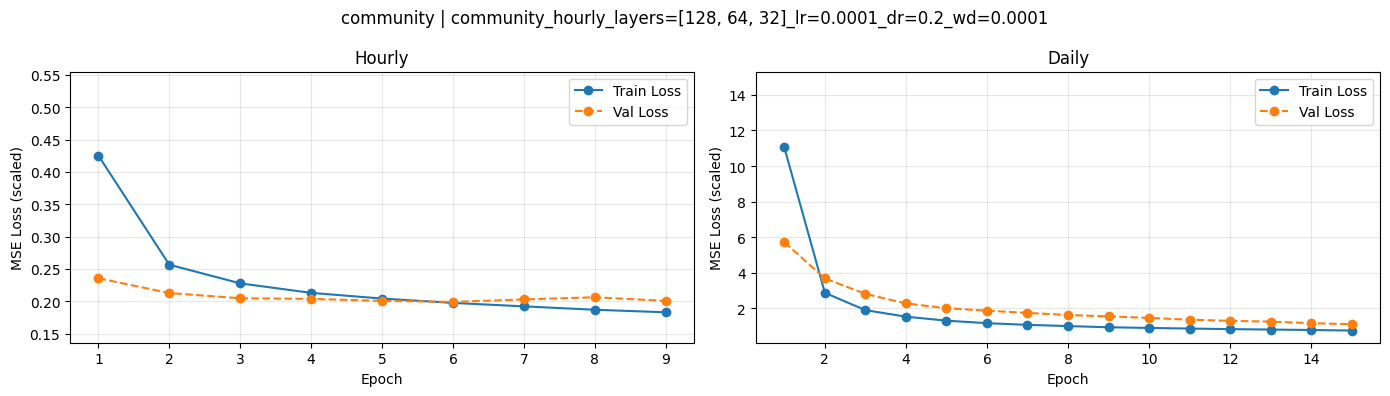

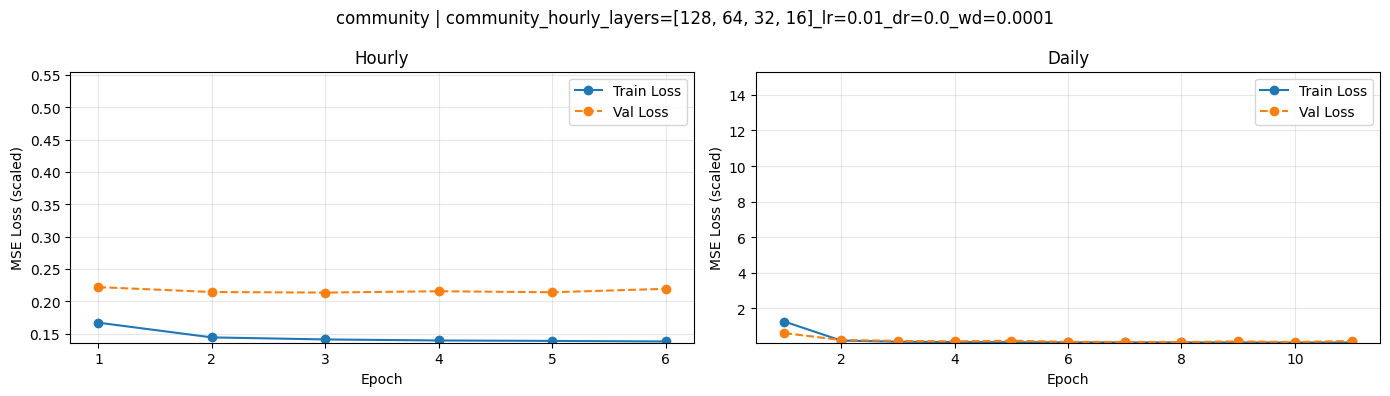

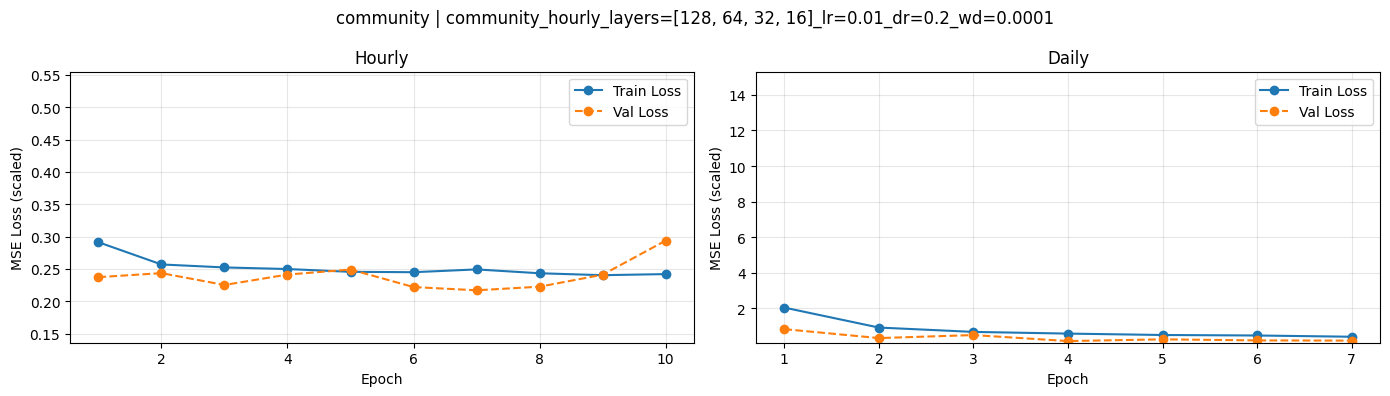

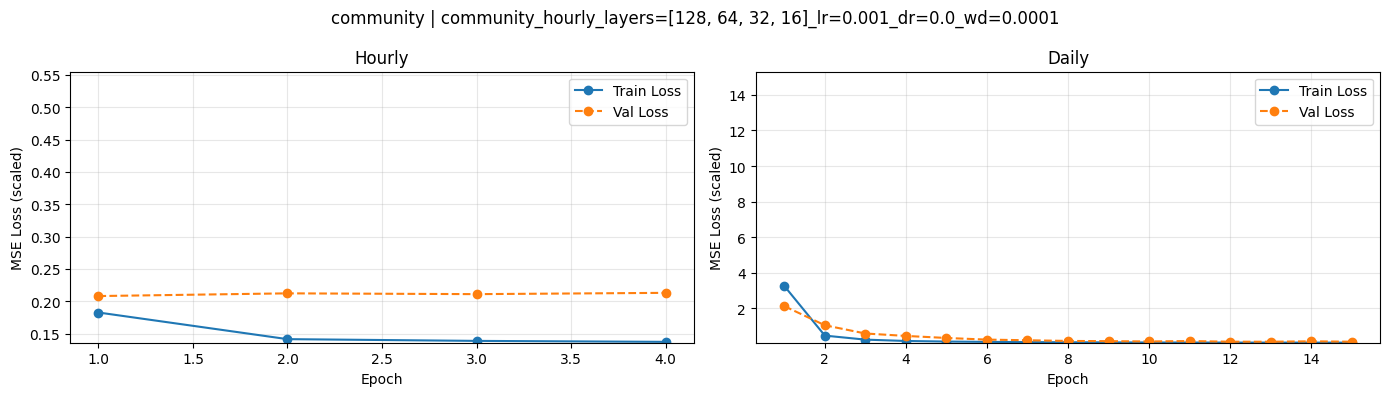

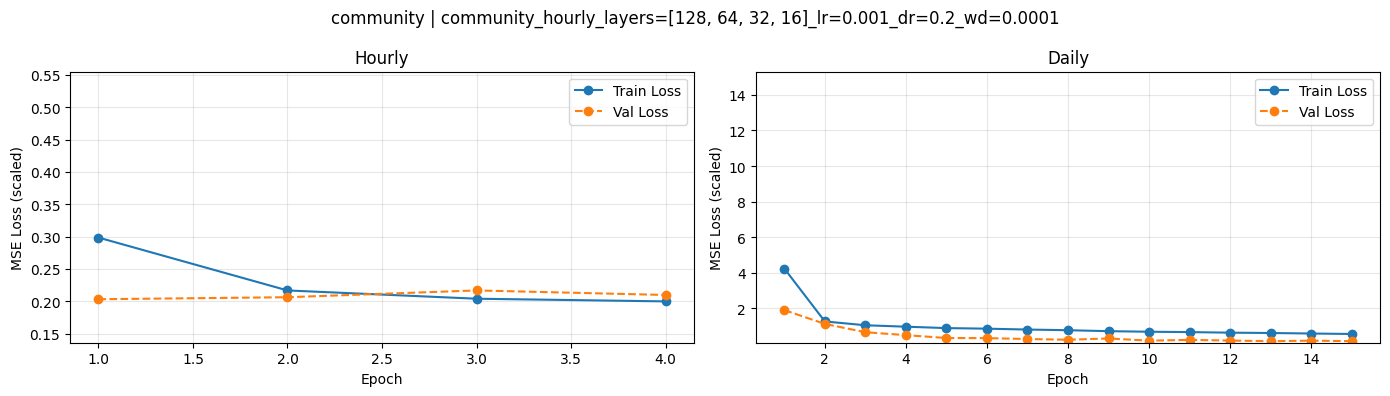

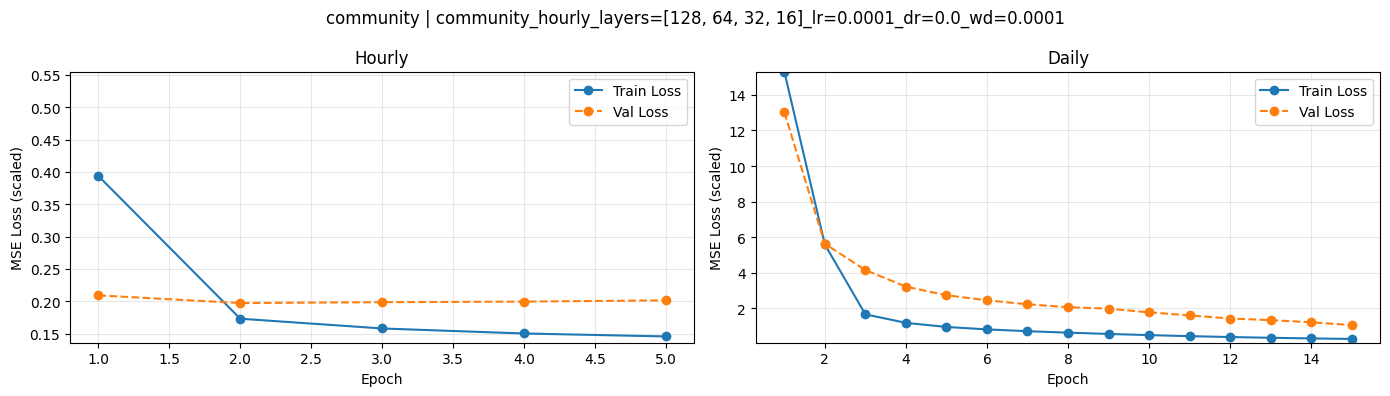

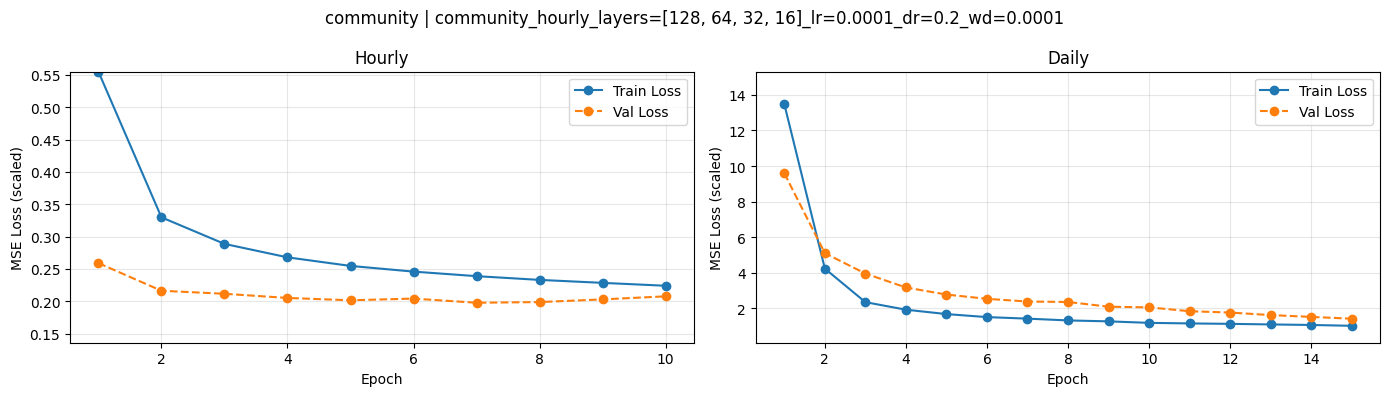

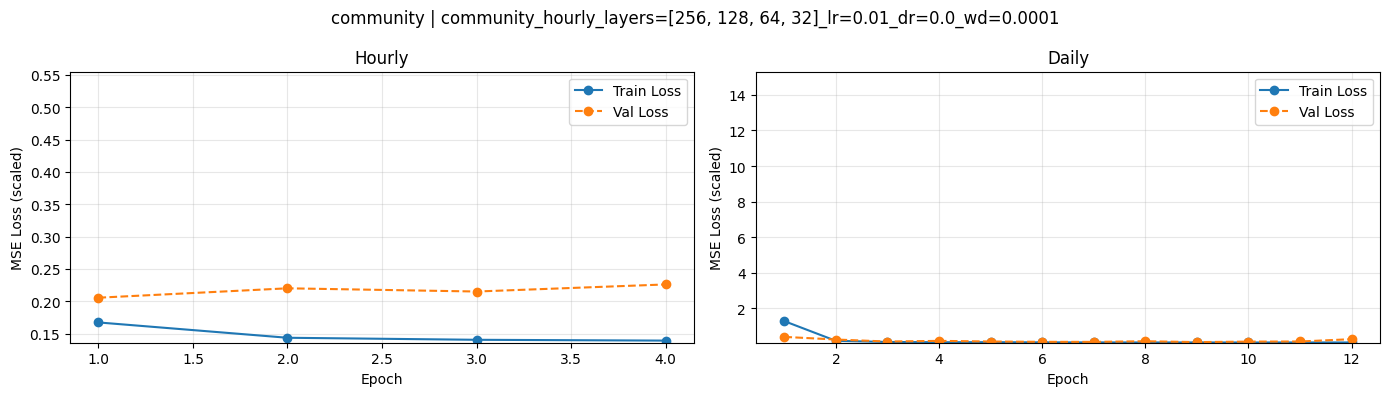

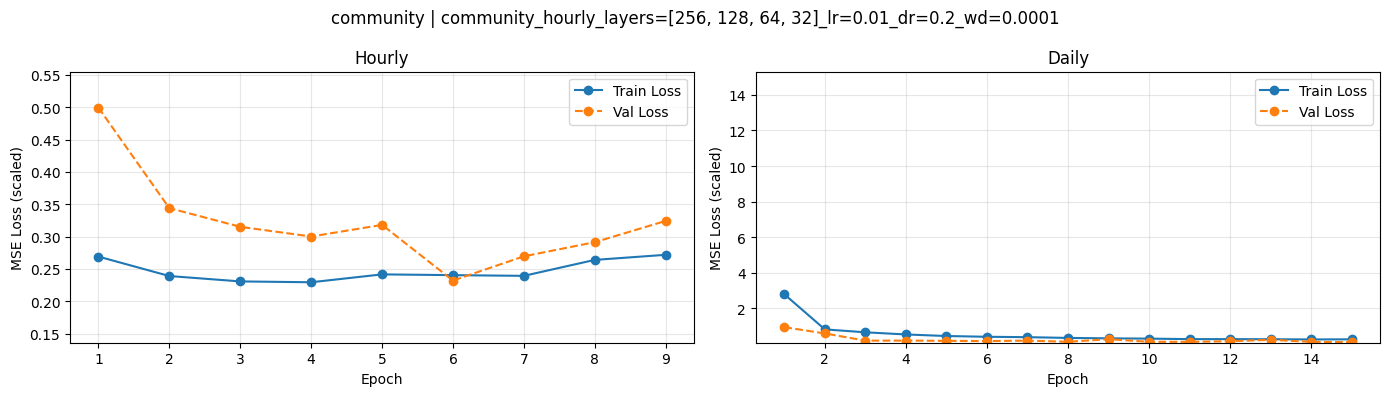

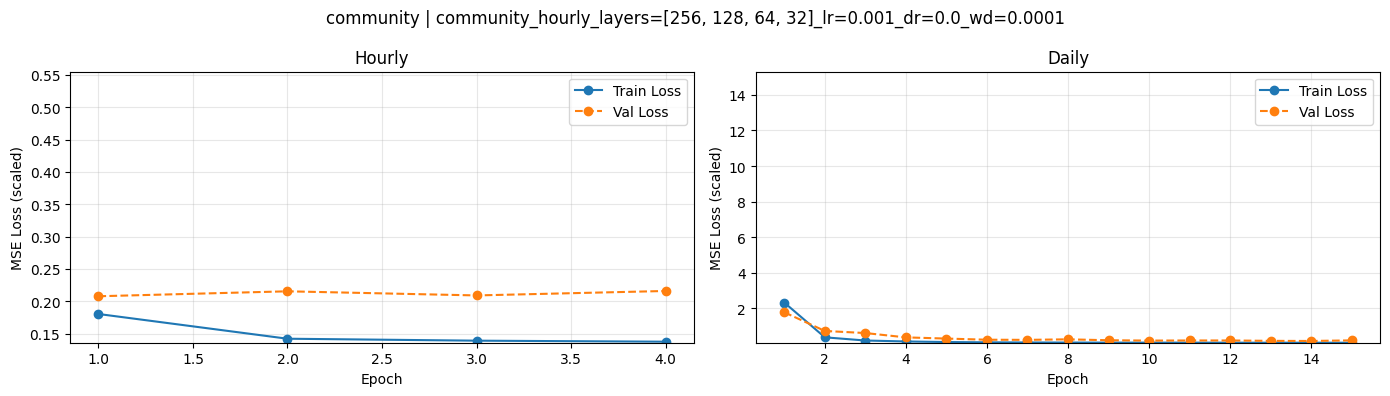

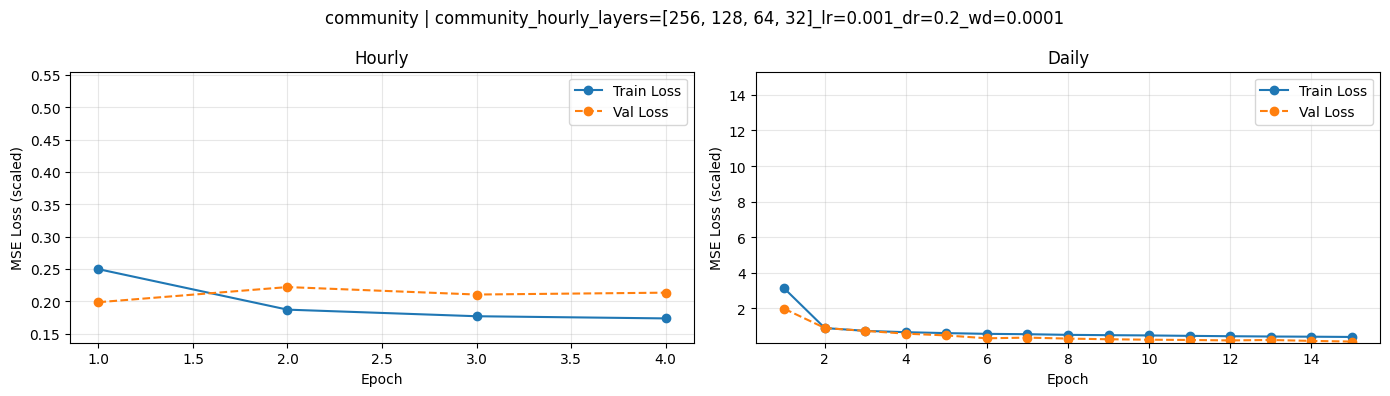

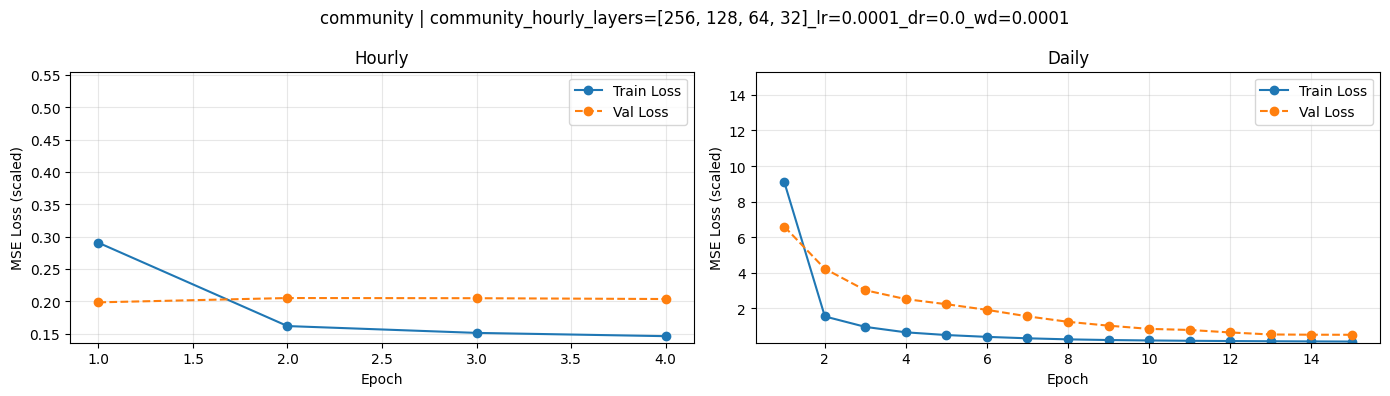

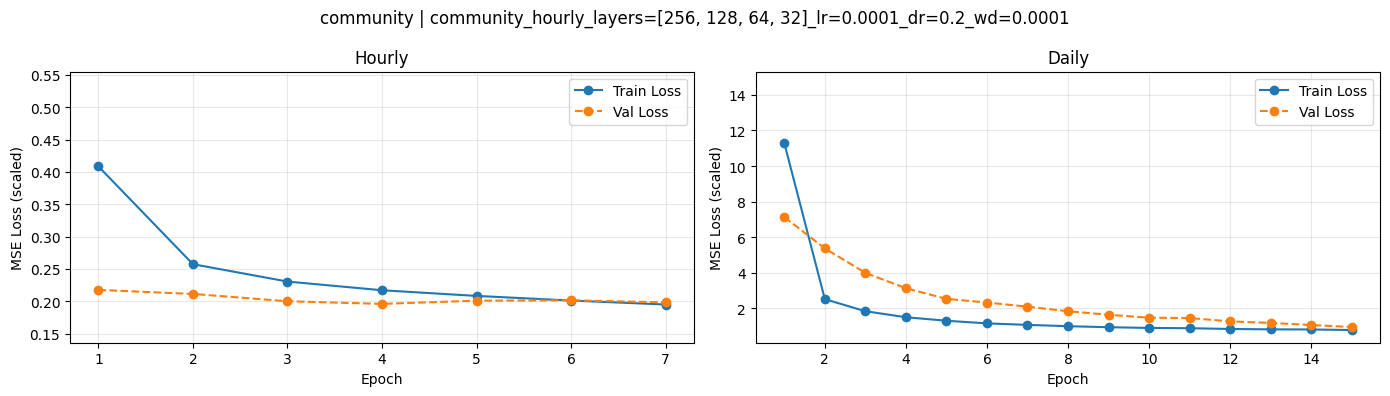

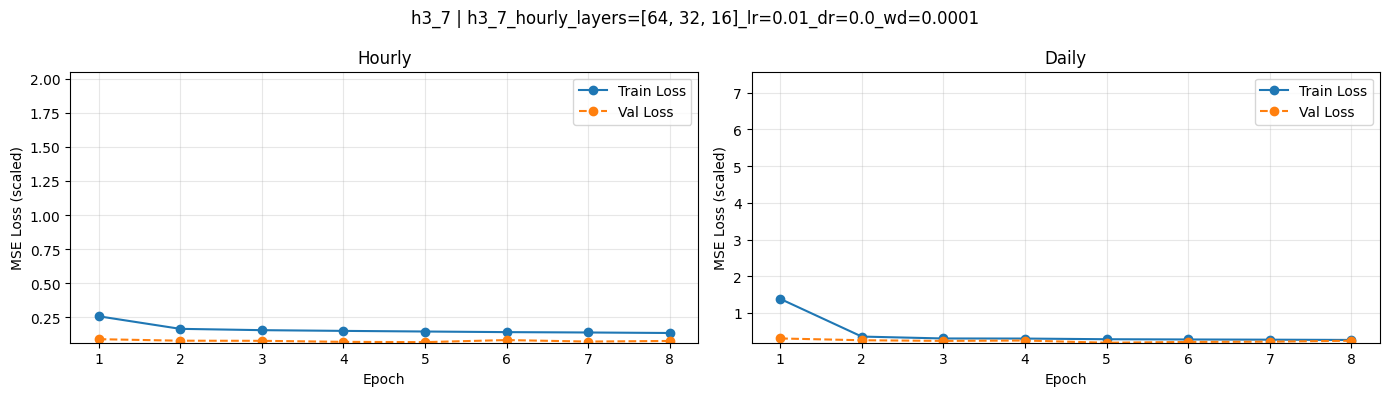

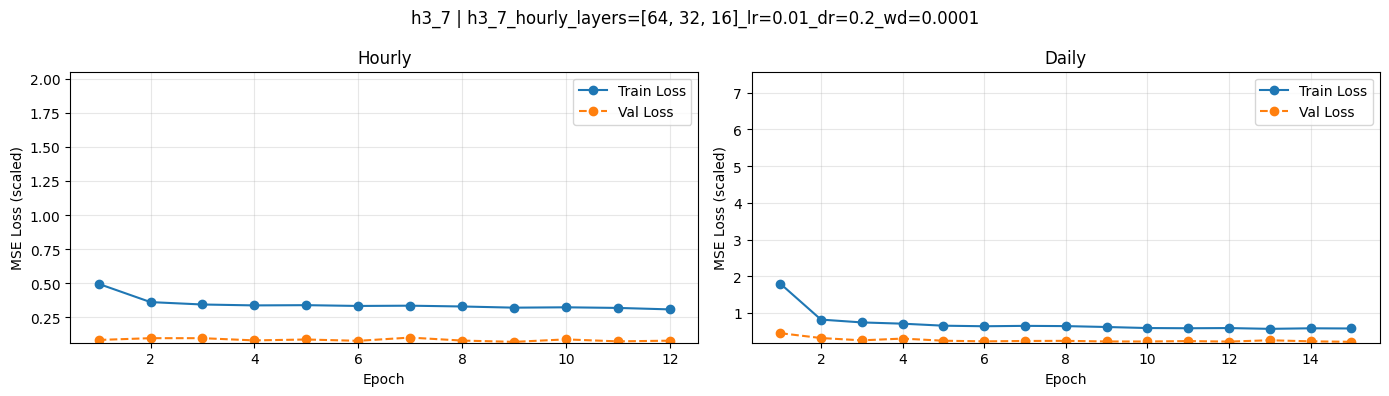

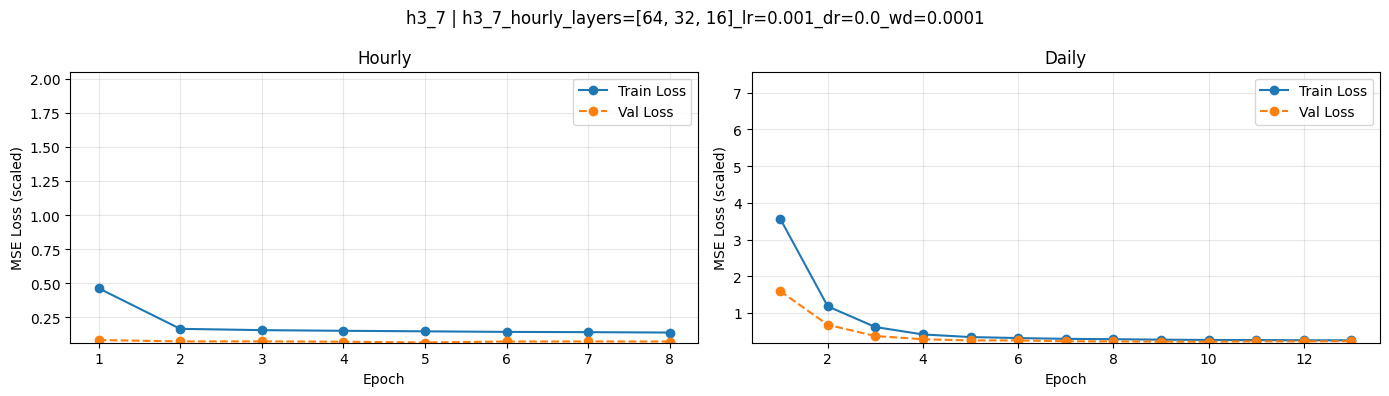

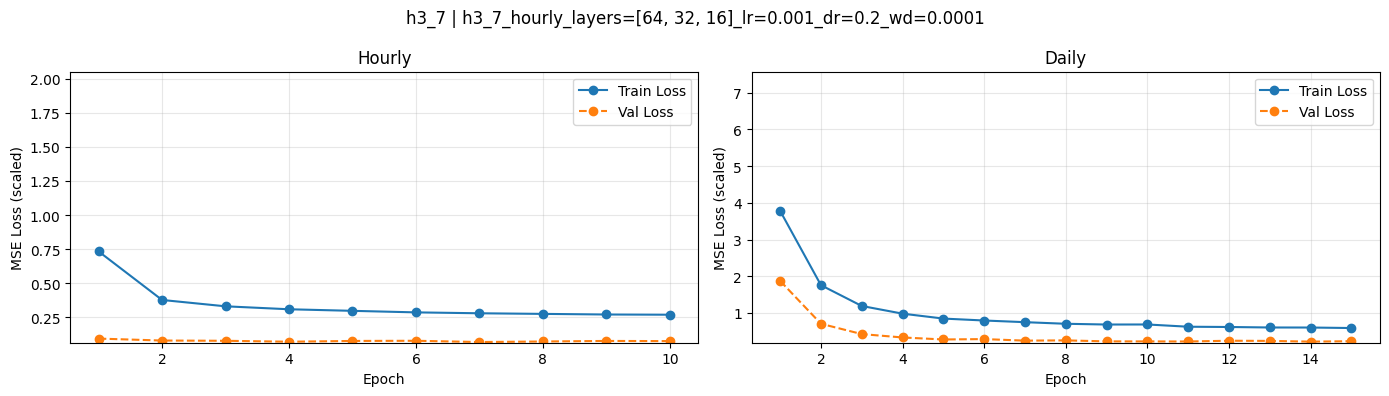

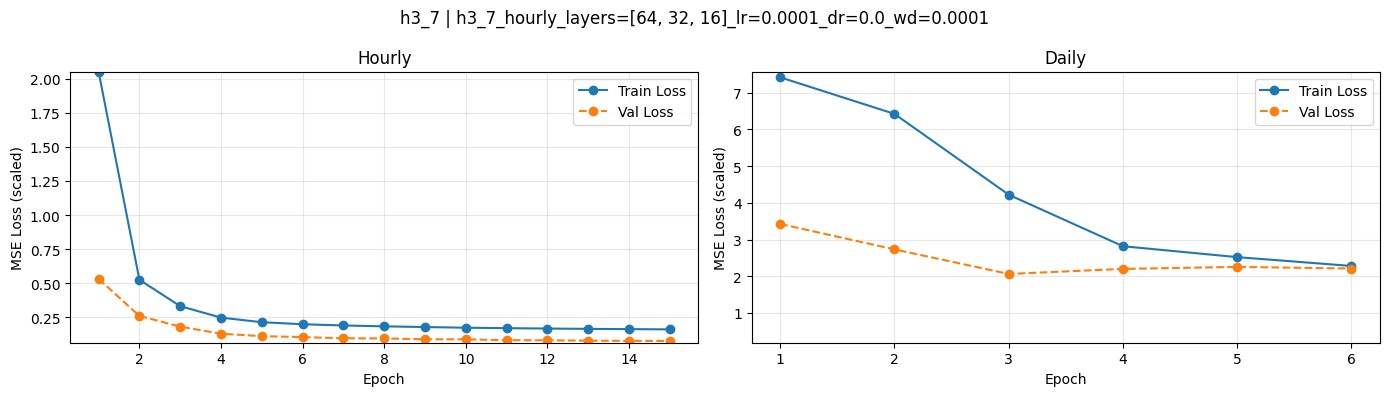

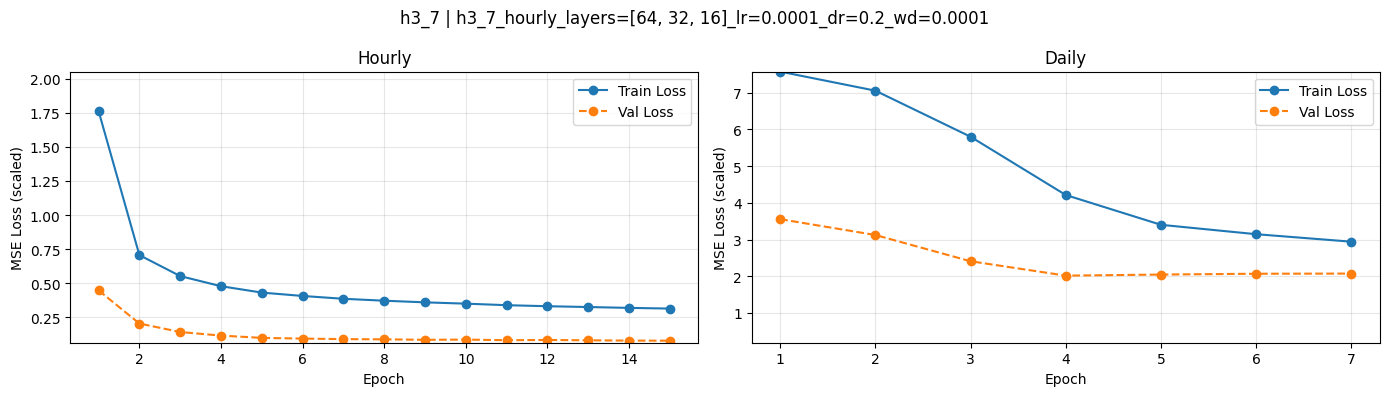

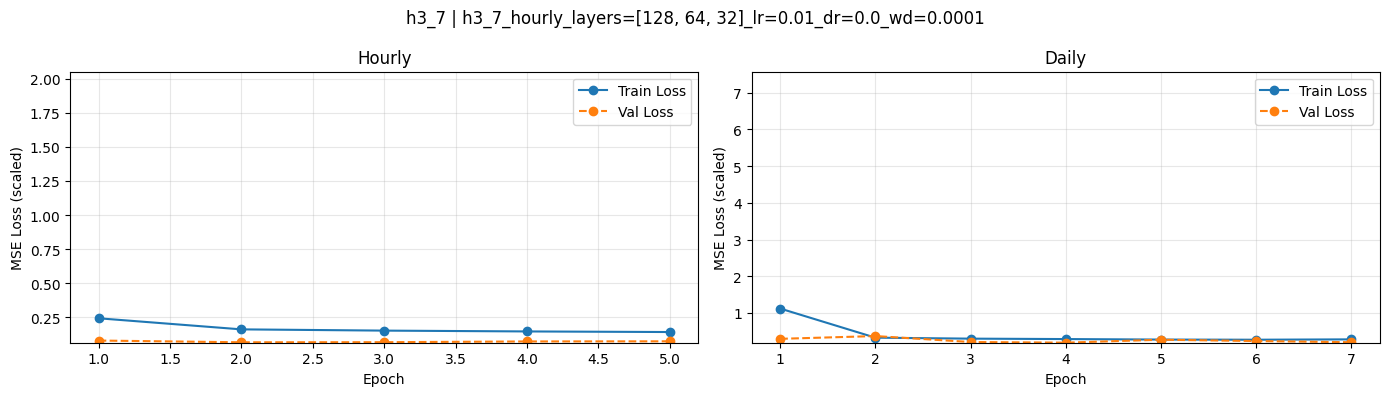

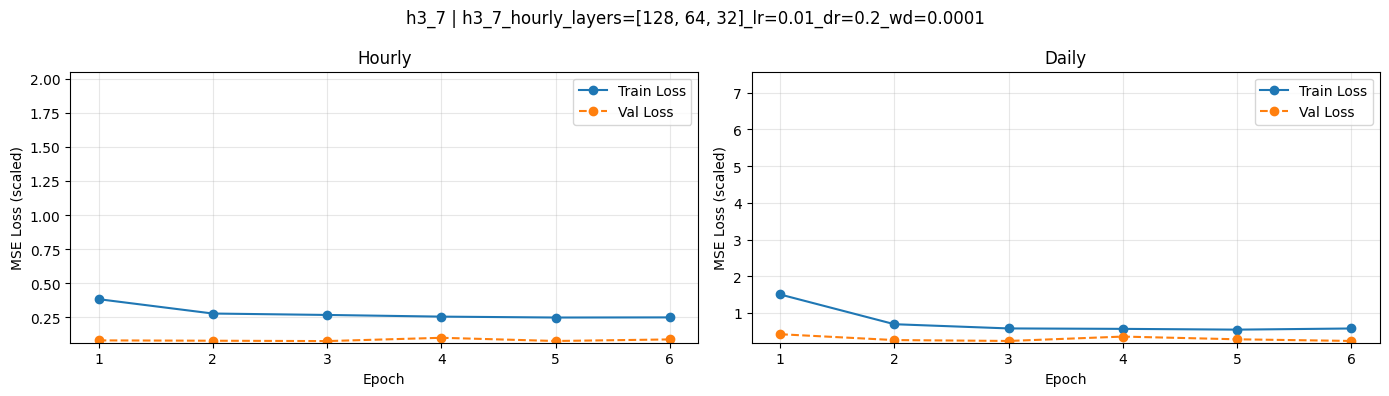

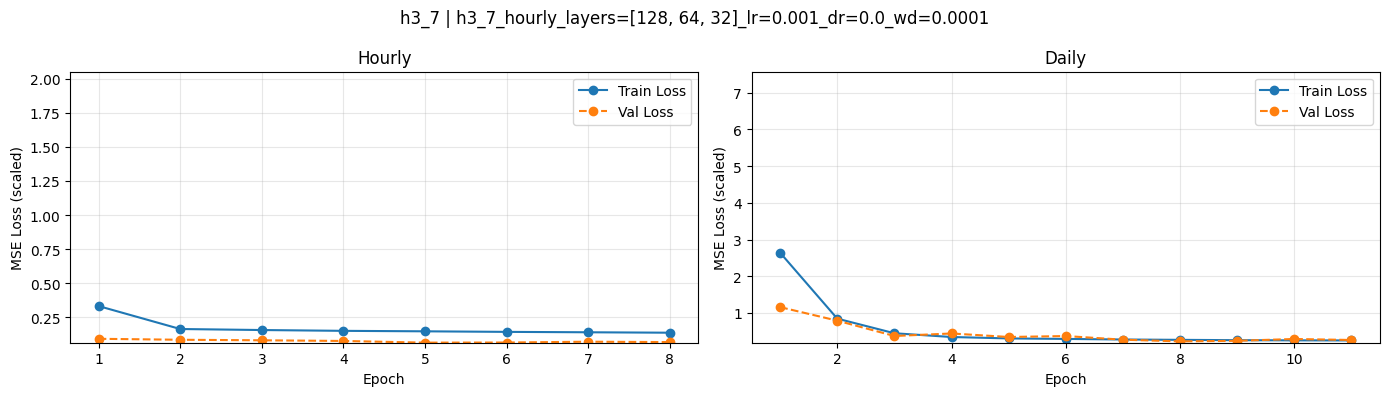

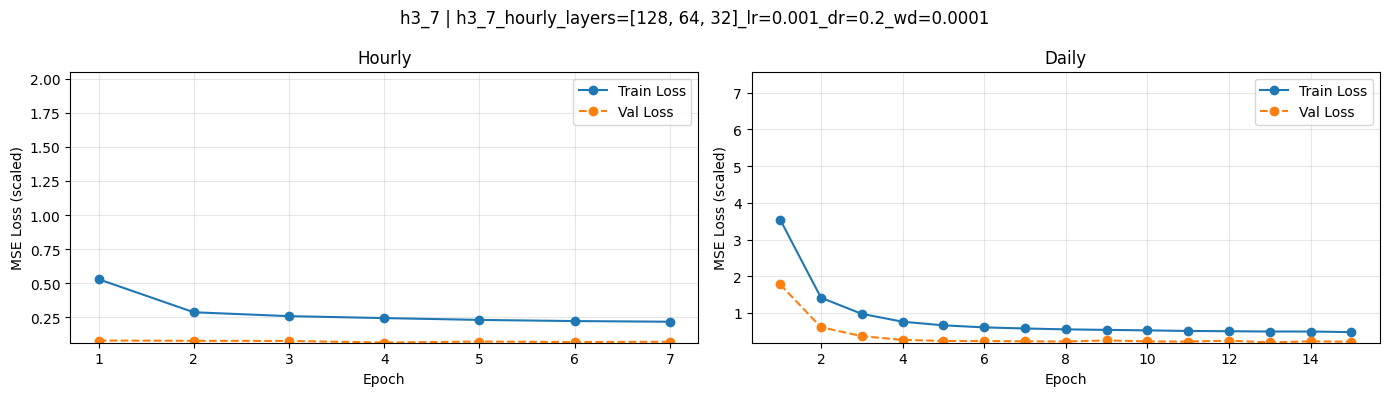

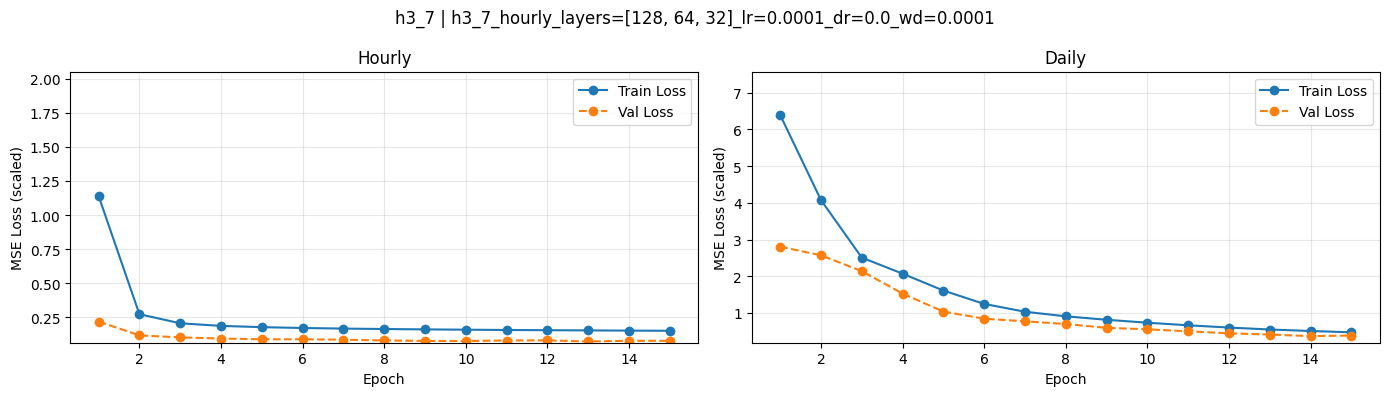

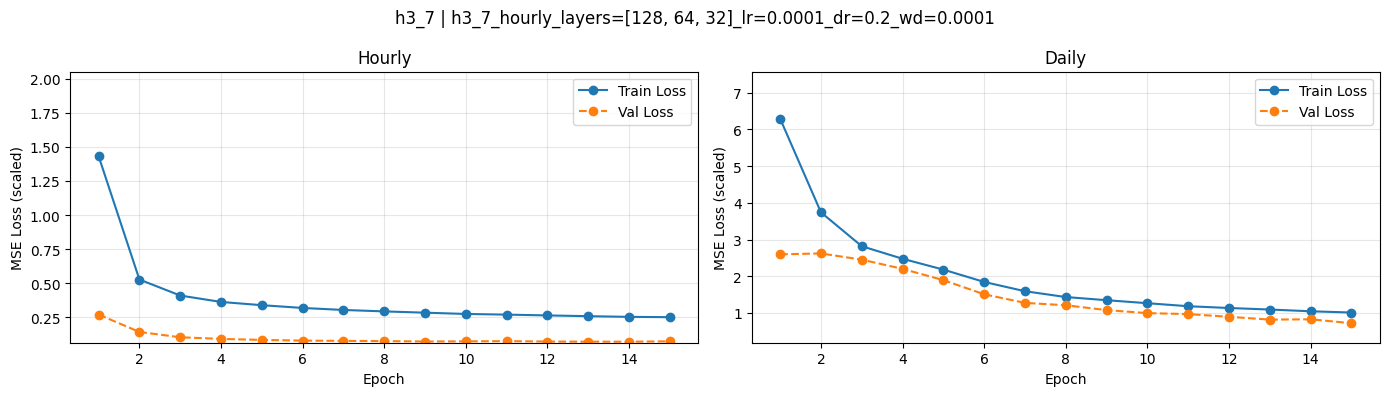

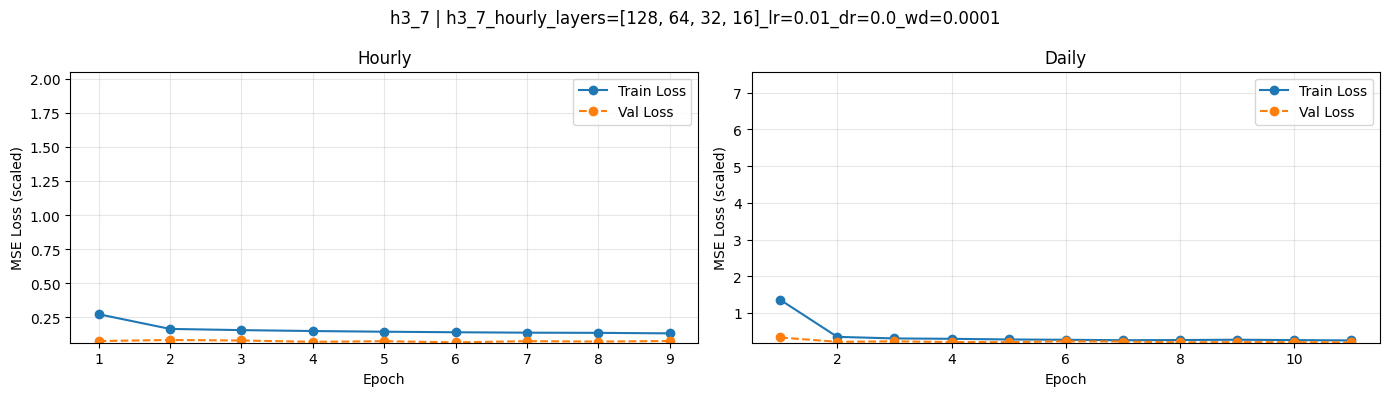

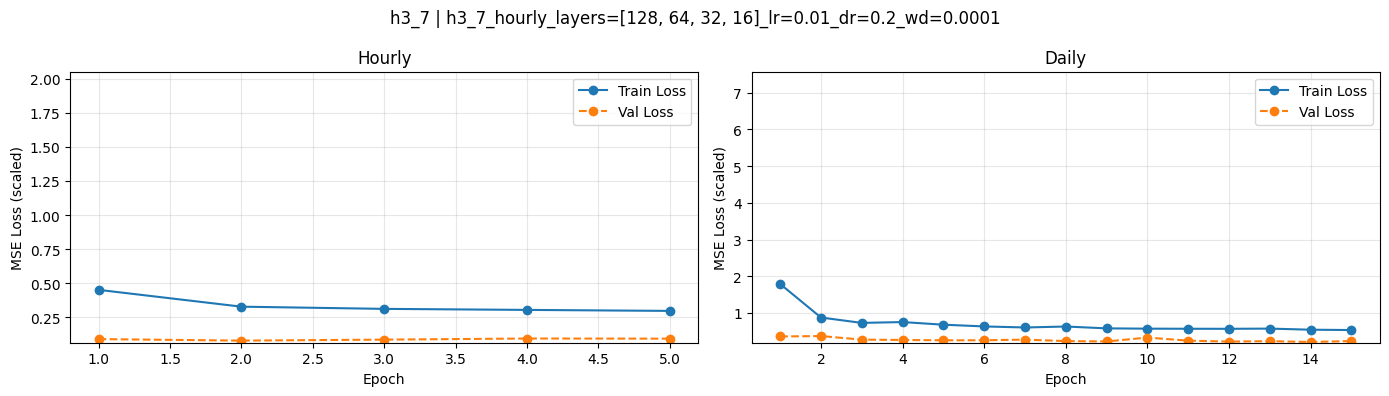

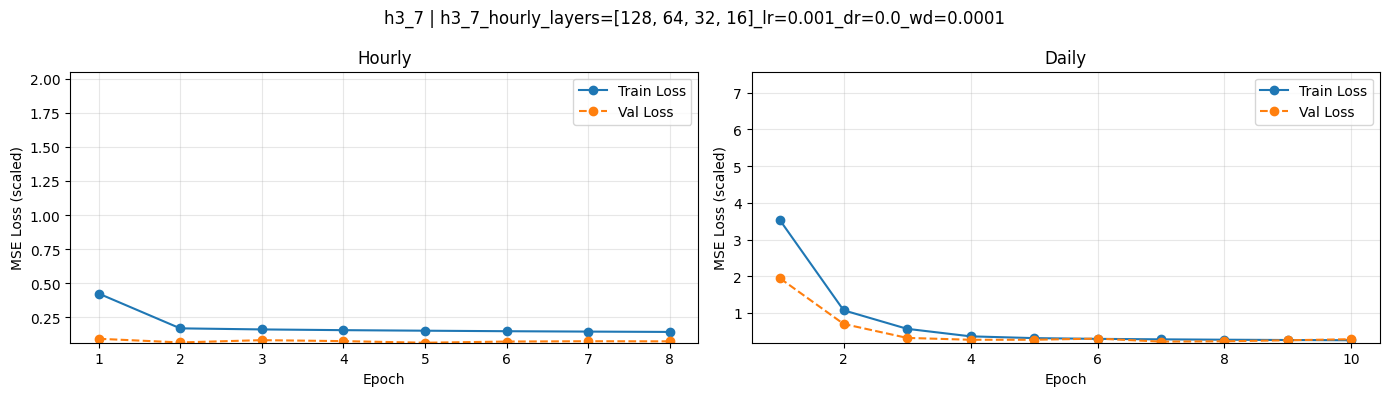

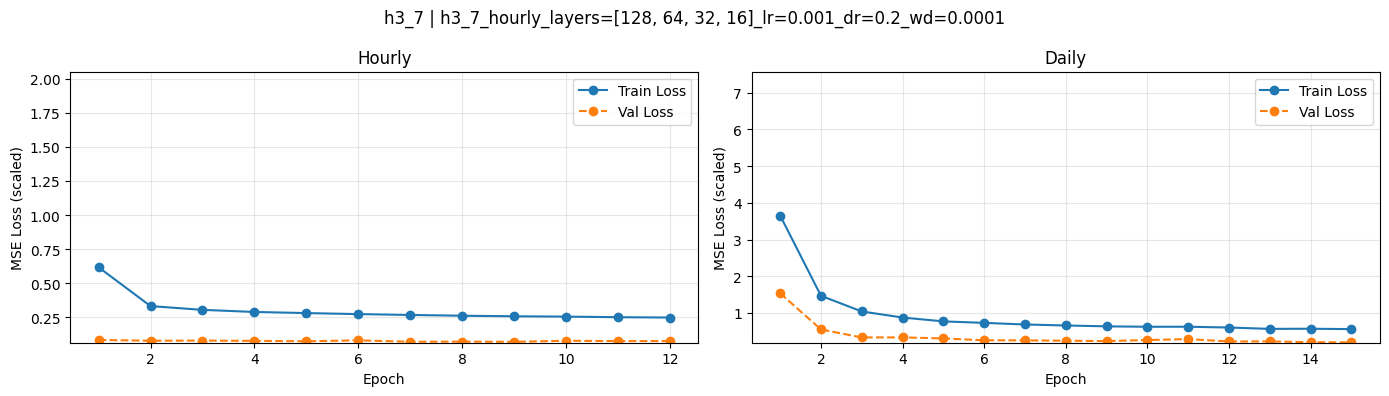

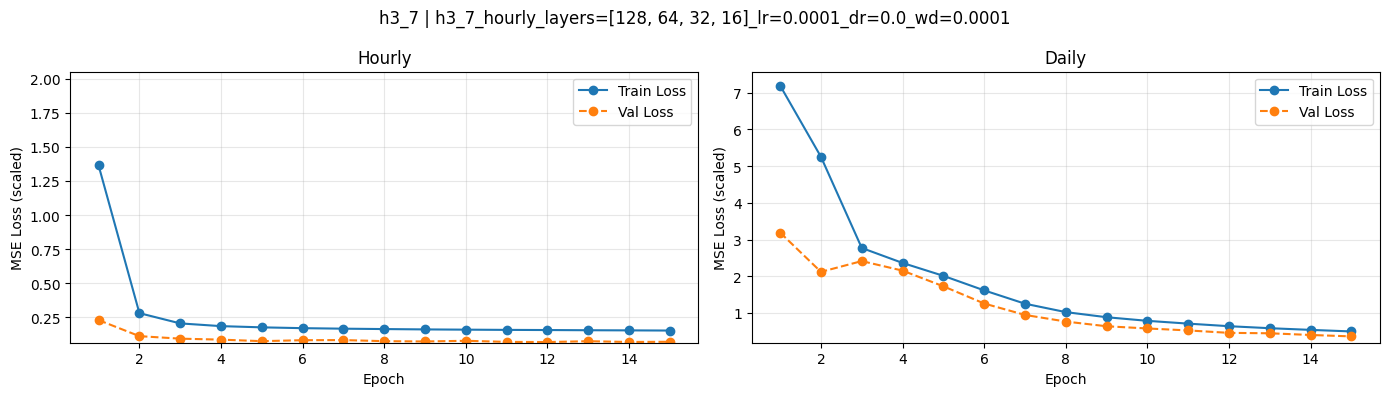

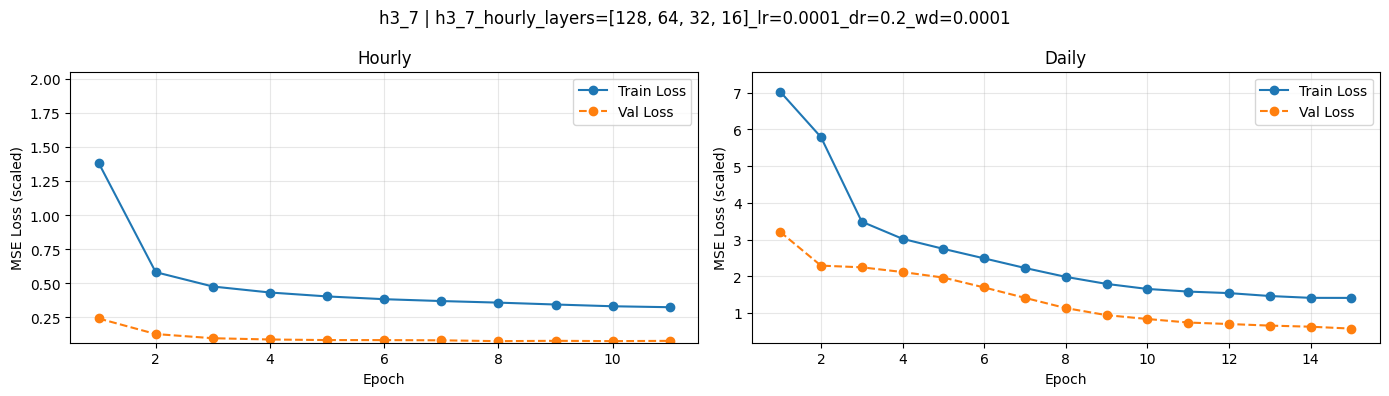

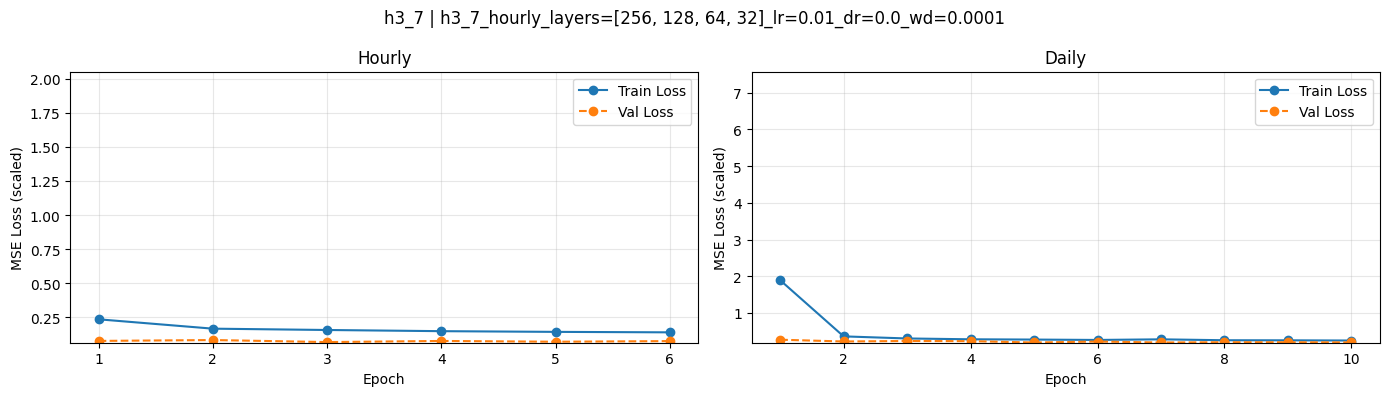

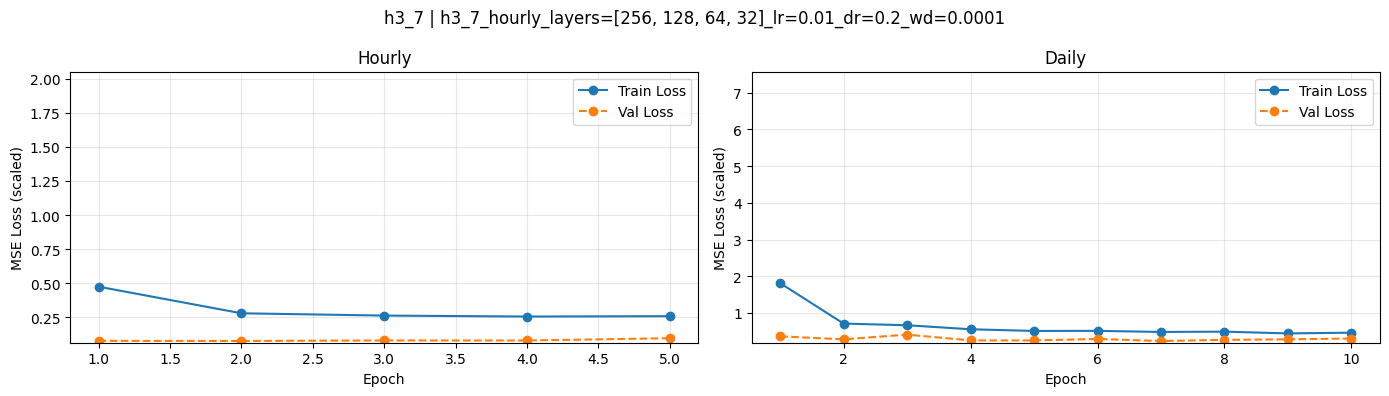

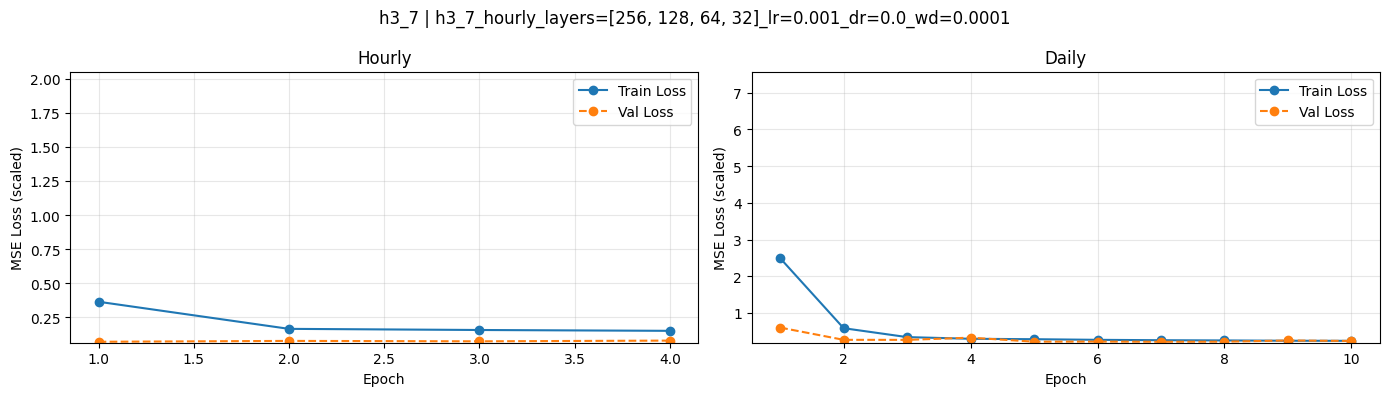

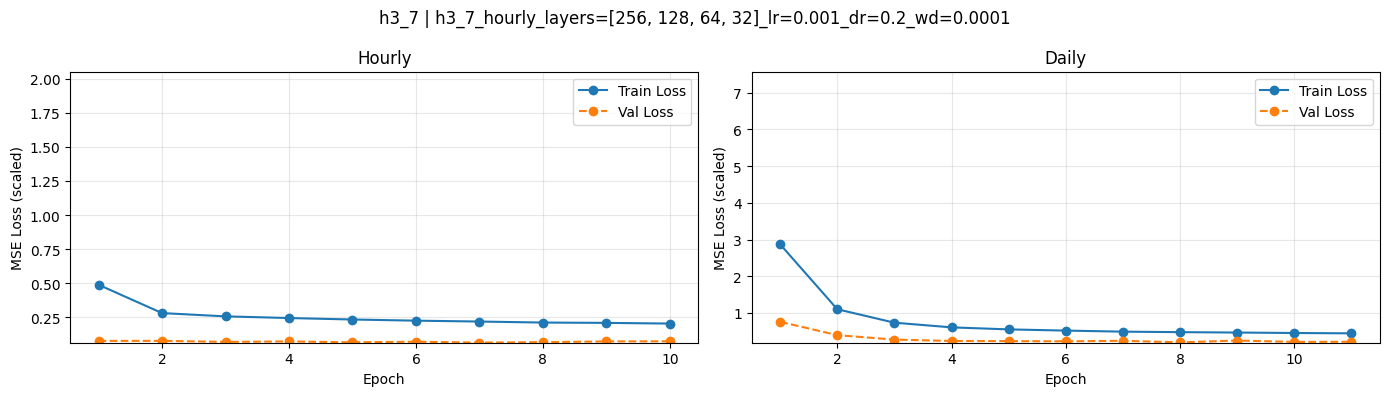

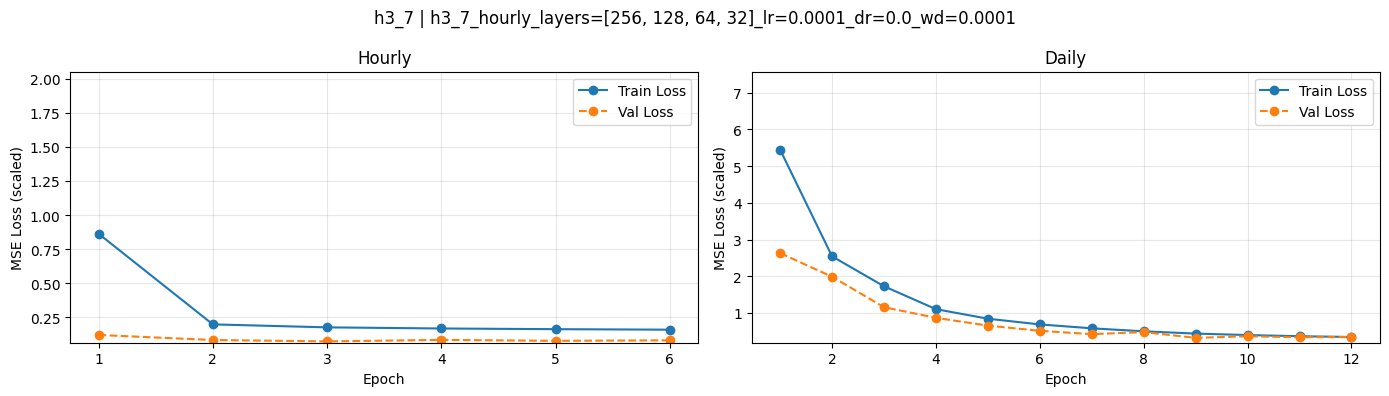

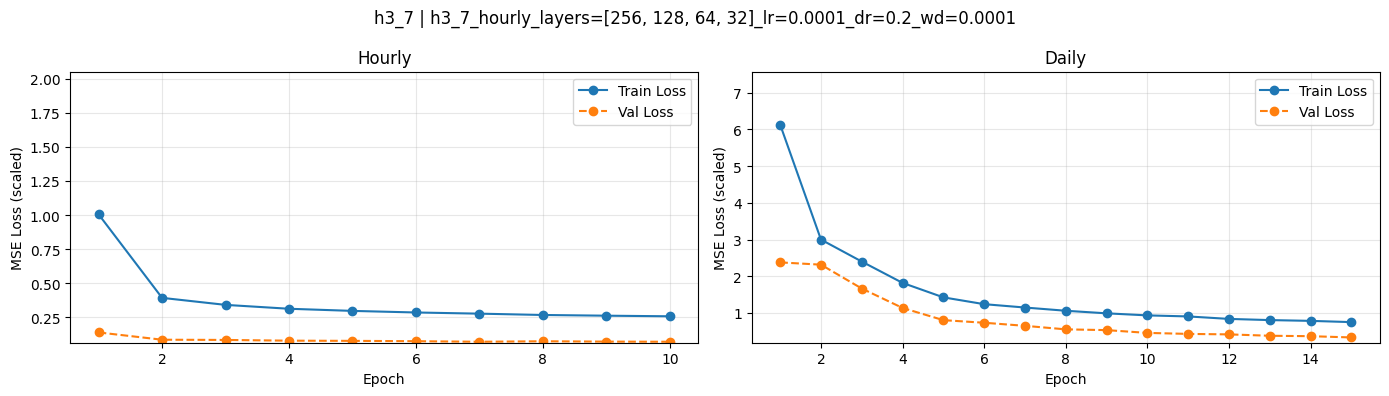

In [13]:
for spatial in spatial_variants:
    df_hourly = all_results[(spatial, "hourly")]
    df_daily = all_results[(spatial, "daily")]

    y_max_hourly = df_hourly[["train_loss", "val_loss"]].max().max()
    y_min_hourly = df_hourly[["train_loss", "val_loss"]].min().min()
    y_max_daily = df_daily[["train_loss", "val_loss"]].max().max()
    y_min_daily = df_daily[["train_loss", "val_loss"]].min().min()

    configs = df_hourly["config"].unique()

    for config in configs:
        group_hourly = df_hourly[df_hourly["config"] == config]
        config_daily = config.replace("_hourly_", "_daily_")
        group_daily = df_daily[df_daily["config"] == config_daily]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
        fig.suptitle(f"{spatial} | {config}")

        ax1.plot(group_hourly["epoch"], group_hourly["train_loss"], label="Train Loss", marker="o")
        ax1.plot(group_hourly["epoch"], group_hourly["val_loss"], label="Val Loss", marker="o", linestyle="--")
        ax1.set_title("Hourly")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("MSE Loss (scaled)")
        ax1.set_ylim(y_min_hourly, y_max_hourly)
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        ax2.plot(group_daily["epoch"], group_daily["train_loss"], label="Train Loss", marker="o")
        ax2.plot(group_daily["epoch"], group_daily["val_loss"], label="Val Loss", marker="o", linestyle="--")
        ax2.set_title("Daily")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("MSE Loss (scaled)")
        ax2.set_ylim(y_min_daily, y_max_daily)
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f"../models_predictions/FNN/standard/{spatial}/learning_curve_{config}.png", dpi=150)
        plt.show()

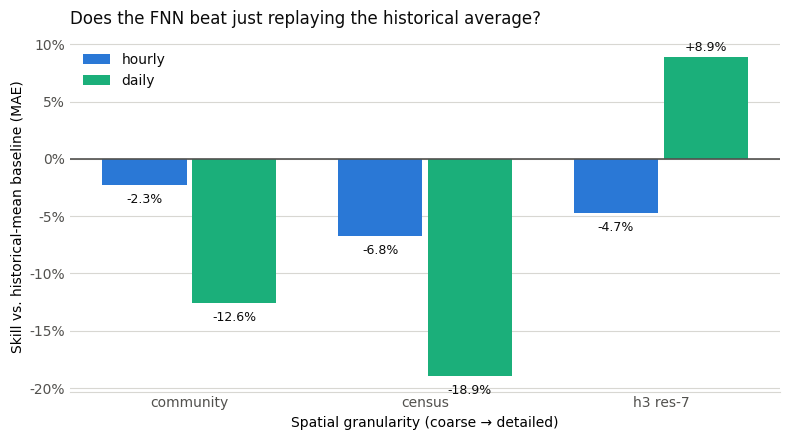

In [14]:
# Skill-vs-baseline chart, using the shared helper from 3.2 Prediction_CommonGround.ipynb so the
# FNN chart matches the SVR ones exactly (white background, same palette/styling).
plot_skill_by_level(scores_df, title="Does the FNN beat just replaying the historical average?")